# Home Credit: Data Cleaning, Outliers, and Correlations

This notebook is exploratory and preprocessing-only. It does **not drop rows**, **does not remove columns**, and **does not cap outliers**. It measures IQR outliers, studies numeric and categorical relationships, chooses imputers, then fits one-hot preprocessing on train and applies it to test. `TARGET` and `SK_ID_CURR` are excluded from model features.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style='whitegrid')
RANDOM_SEED = 42
ID_COL = 'SK_ID_CURR'
TARGET_COL = 'TARGET'

def find_data_root():
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / 'input' / 'train.csv').is_file():
            return folder
    raise FileNotFoundError('Could not find input/train.csv from this notebook directory.')

DATA_ROOT = find_data_root()
train = pd.read_csv(DATA_ROOT / 'input' / 'train.csv')
test = pd.read_csv(DATA_ROOT / 'input' / 'test.csv')
train_rows_before = len(train)
test_rows_before = len(test)
print('Data folder:', DATA_ROOT)
print('Train shape:', train.shape, '| Test shape:', test.shape)
print('Target default rate:', train[TARGET_COL].mean())
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert train[TARGET_COL].isin([0, 1]).all()
assert train_rows_before == len(train) and test_rows_before == len(test)
train.head()

Data folder: d:\GCI\04. Competition (due XX)-20261005T035138Z-1-001\04. Competition (due XX)\Competition
Train shape: (171202, 34) | Test shape: (61500, 33)
Target default rate: 0.08072919708881905


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET
0,0,Cash loans,F,0,112500.0,755190.0,36328.5,675000.0,Working,Higher education,...,School,NaN,0.372591,NaN,-292.0,NaN,NaN,NaN,NaN,0
1,1,Cash loans,F,0,225000.0,585000.0,16893.0,585000.0,Pensioner,Secondary / secondary special,...,XNA,NaN,0.449567,0.553165,-617.0,0.0,0.0,0.0,1.0,0
2,2,Cash loans,F,0,54000.0,334152.0,18256.5,270000.0,State servant,Secondary / secondary special,...,Postal,NaN,0.569503,NaN,-542.0,NaN,NaN,NaN,NaN,0
3,3,Cash loans,F,0,67500.0,152820.0,8901.0,135000.0,Pensioner,Lower secondary,...,XNA,NaN,0.105235,0.767523,0.0,0.0,0.0,0.0,0.0,0
4,4,Cash loans,M,0,157500.0,271066.5,21546.0,234000.0,Commercial associate,Secondary / secondary special,...,Business Entity Type 3,0.342344,0.202490,0.669057,-1243.0,0.0,0.0,0.0,4.0,1


## 1. Schema and Missingness

Keep IDs for later submission alignment, but do not treat the ID as a predictive measurement. Summarize all predictor columns and missing values in both datasets.

,dtype,train_missing,train_missing_pct,test_missing,test_missing_pct,n_unique_train
EXT_SOURCE_1,float64,118928,69.466478,42912,69.775610,49131
OWN_CAR_AGE,float64,112992,65.999229,40909,66.518699,54
EXT_SOURCE_3,float64,54586,31.883973,19690,32.016260,784
AMT_REQ_CREDIT_BUREAU_QRT,float64,23116,13.502179,8513,13.842276,11
AMT_REQ_CREDIT_BUREAU_MON,float64,23116,13.502179,8513,13.842276,21
AMT_REQ_CREDIT_BUREAU_HOUR,float64,23116,13.502179,8513,13.842276,5
AMT_REQ_CREDIT_BUREAU_YEAR,float64,23116,13.502179,8513,13.842276,23
EXT_SOURCE_2,float64,369,0.215535,130,0.211382,90952
CNT_FAM_MEMBERS,float64,2,0.001168,0,0.000000,15
NAME_INCOME_TYPE,object,0,0.000000,0,0.000000,8


Numeric predictors: 24 | Categorical predictors: 8
Duplicate complete training rows: 0


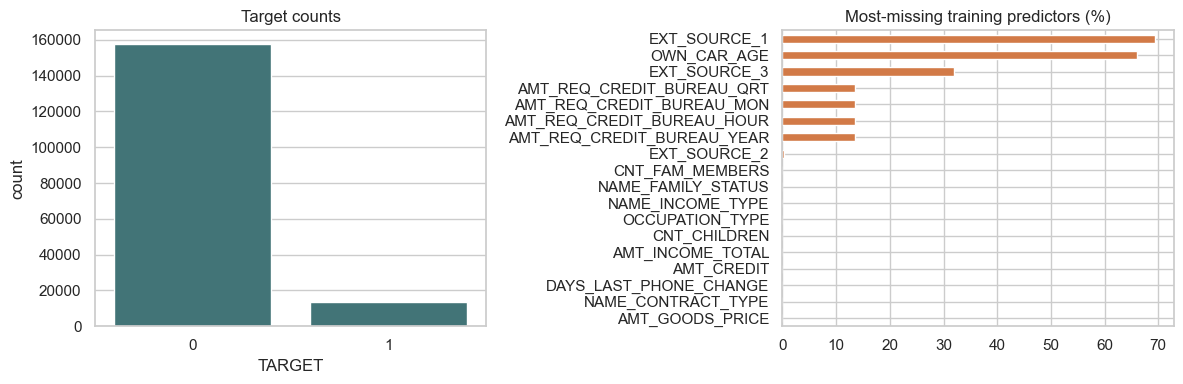

In [11]:
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET_COL]]
X_raw = train[feature_cols].copy()
X_test_raw = test[feature_cols].copy()
y = train[TARGET_COL].astype('int8').copy()
numeric_cols = X_raw.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_raw.select_dtypes(exclude=np.number).columns.tolist()

schema = pd.DataFrame({
    'dtype': X_raw.dtypes.astype(str),
    'train_missing': X_raw.isna().sum(),
    'train_missing_pct': X_raw.isna().mean().mul(100),
    'test_missing': X_test_raw.isna().sum(),
    'test_missing_pct': X_test_raw.isna().mean().mul(100),
    'n_unique_train': X_raw.nunique(dropna=True),
}).sort_values('train_missing_pct', ascending=False)
display(schema)
print(f'Numeric predictors: {len(numeric_cols)} | Categorical predictors: {len(categorical_cols)}')
print('Duplicate complete training rows:', int(train.duplicated().sum()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train, x=TARGET_COL, ax=axes[0], color='#397c80')
axes[0].set_title('Target counts')
missing_pct = schema['train_missing_pct'].sort_values().tail(18)
missing_pct.plot.barh(ax=axes[1], color='#d27a47')
axes[1].set_title('Most-missing training predictors (%)')
plt.tight_layout(); plt.show()

### Train/Test, ID, Date, and Type Audit

Check that train and test predictors match, compare their feature distributions, identify numeric-coded low-cardinality fields, and search for actual calendar-date columns. Keep `SK_ID_CURR` for row matching/submission, but exclude it from `X_raw`; do not mistake identifier order for a timestamp.

## 2. Outlier Counts (No Rows Removed)

Use the 1.5×IQR rule as a **screening flag**, not as a rule that values are errors. This rule can flag many valid observations in skewed or zero-heavy financial features. A special value such as `DAYS_EMPLOYED = 365243` is also flagged statistically, but is a known sentinel that should be interpreted separately. No rows are clipped or dropped here.

,lower_iqr_bound,upper_iqr_bound,outlier_count,outlier_pct_of_rows,missing_count
feature,,,,,
REGION_RATING_CLIENT,2.000000,2.000000e+00,44800,26.167919,0
DAYS_EMPLOYED,-6498.000000,3.438000e+03,40224,23.495053,0
FLAG_WORK_PHONE,0.000000,0.000000e+00,34193,19.972313,0
FLAG_EMP_PHONE,1.000000,1.000000e+00,30903,18.050607,0
AMT_REQ_CREDIT_BUREAU_QRT,0.000000,0.000000e+00,28273,16.514410,23116
AMT_REQ_CREDIT_BUREAU_MON,0.000000,0.000000e+00,24353,14.224717,23116
AMT_GOODS_PRICE,-423000.000000,1.341000e+06,8197,4.787911,0
AMT_INCOME_TOTAL,-22500.000000,3.375000e+05,7784,4.546676,0
REGION_POPULATION_RELATIVE,-0.017980,5.664850e-02,4624,2.700903,0


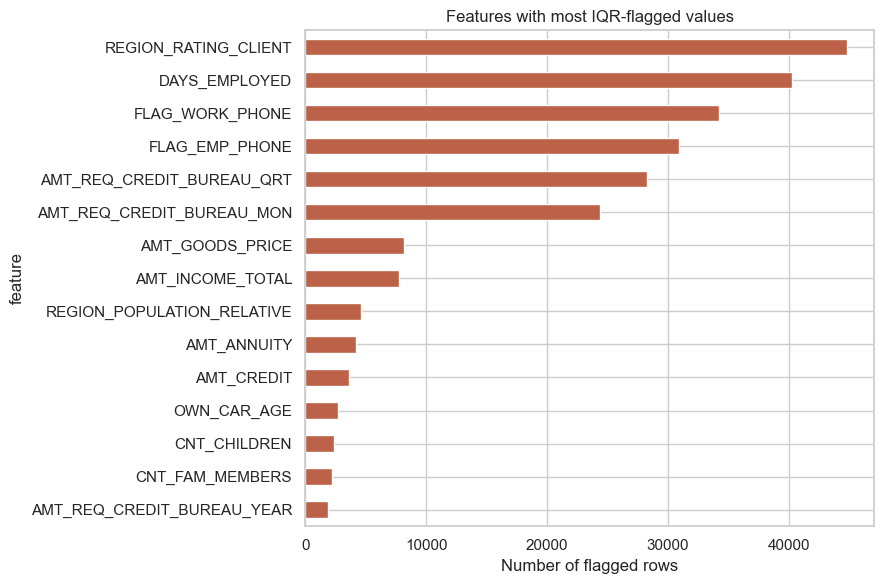

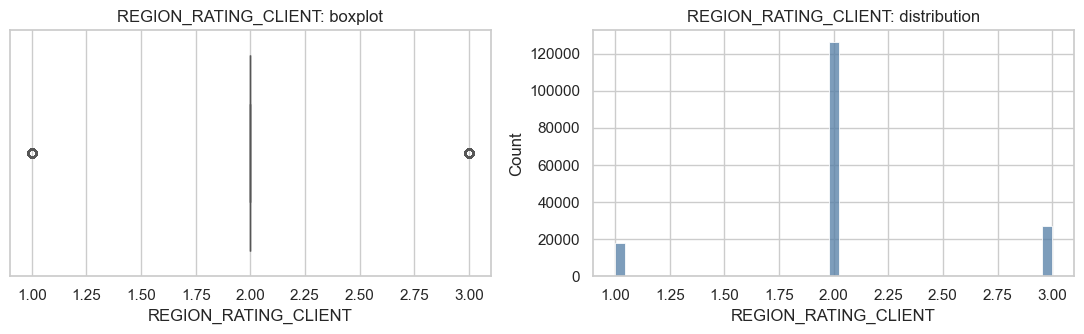

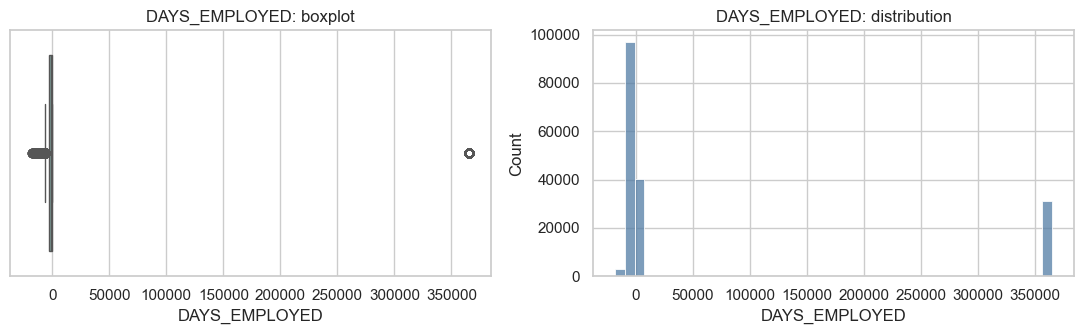

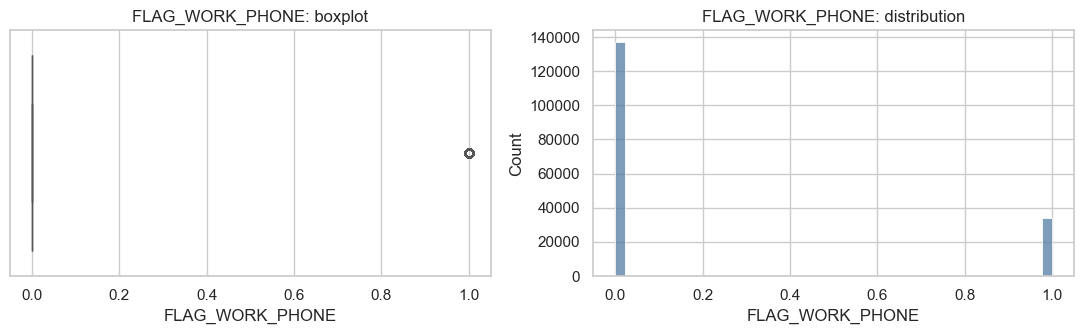

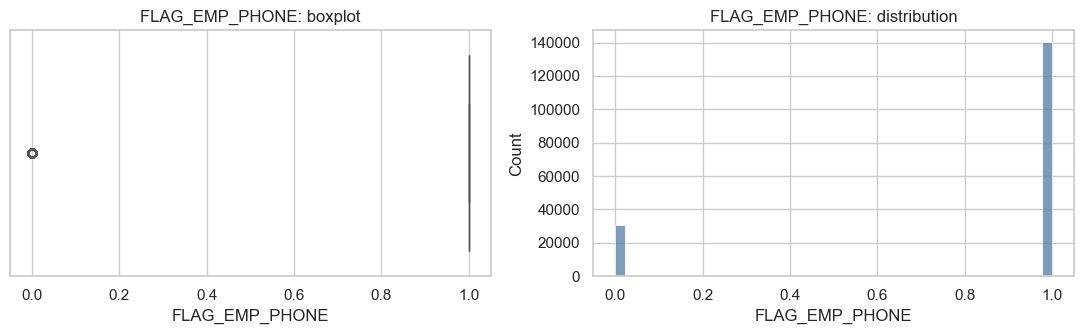

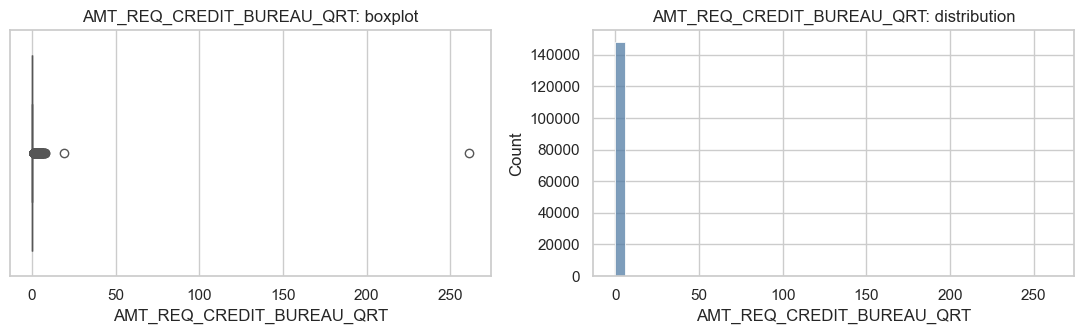

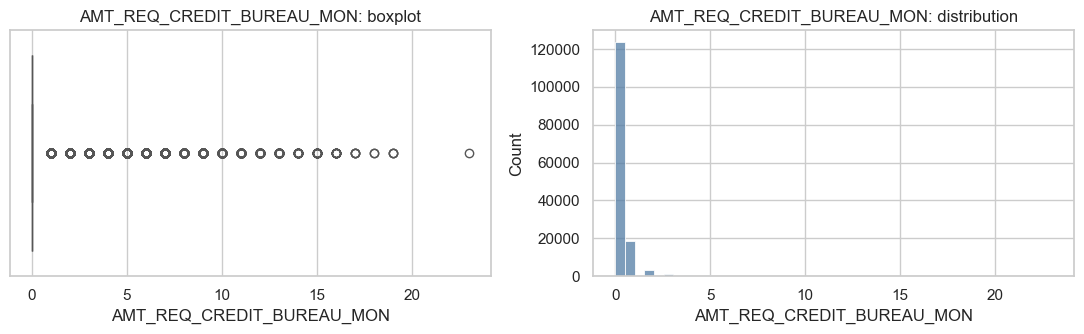

In [3]:
outlier_rows = []
for col in numeric_cols:
    values = X_raw[col].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = X_raw[col].notna() & ((X_raw[col] < lower) | (X_raw[col] > upper))
    outlier_rows.append({
        'feature': col, 'lower_iqr_bound': lower, 'upper_iqr_bound': upper,
        'outlier_count': int(mask.sum()), 'outlier_pct_of_rows': 100 * mask.mean(),
        'missing_count': int(X_raw[col].isna().sum()),
    })
outlier_summary = pd.DataFrame(outlier_rows).set_index('feature').sort_values('outlier_count', ascending=False)
display(outlier_summary)

top_outlier_features = outlier_summary.head(15).sort_values('outlier_count')
fig, ax = plt.subplots(figsize=(9, 6))
top_outlier_features['outlier_count'].plot.barh(ax=ax, color='#bb6248')
ax.set_title('Features with most IQR-flagged values')
ax.set_xlabel('Number of flagged rows')
plt.tight_layout(); plt.show()

# Distribution plots for numeric columns with the most flagged observations.
for col in outlier_summary.head(6).index:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    sns.boxplot(x=X_raw[col], ax=axes[0], color='#7aa6a1')
    sns.histplot(x=X_raw[col], bins=45, ax=axes[1], color='#527ca4')
    axes[0].set_title(f'{col}: boxplot')
    axes[1].set_title(f'{col}: distribution')
    plt.tight_layout(); plt.show()

assert len(train) == train_rows_before, 'No training rows should be removed.'

## 3. Numeric Correlations

Pearson correlation captures linear association; Spearman correlation captures monotonic association and is less sensitive to extreme magnitudes. Both use pairwise available observations. Correlation is not a causal claim.

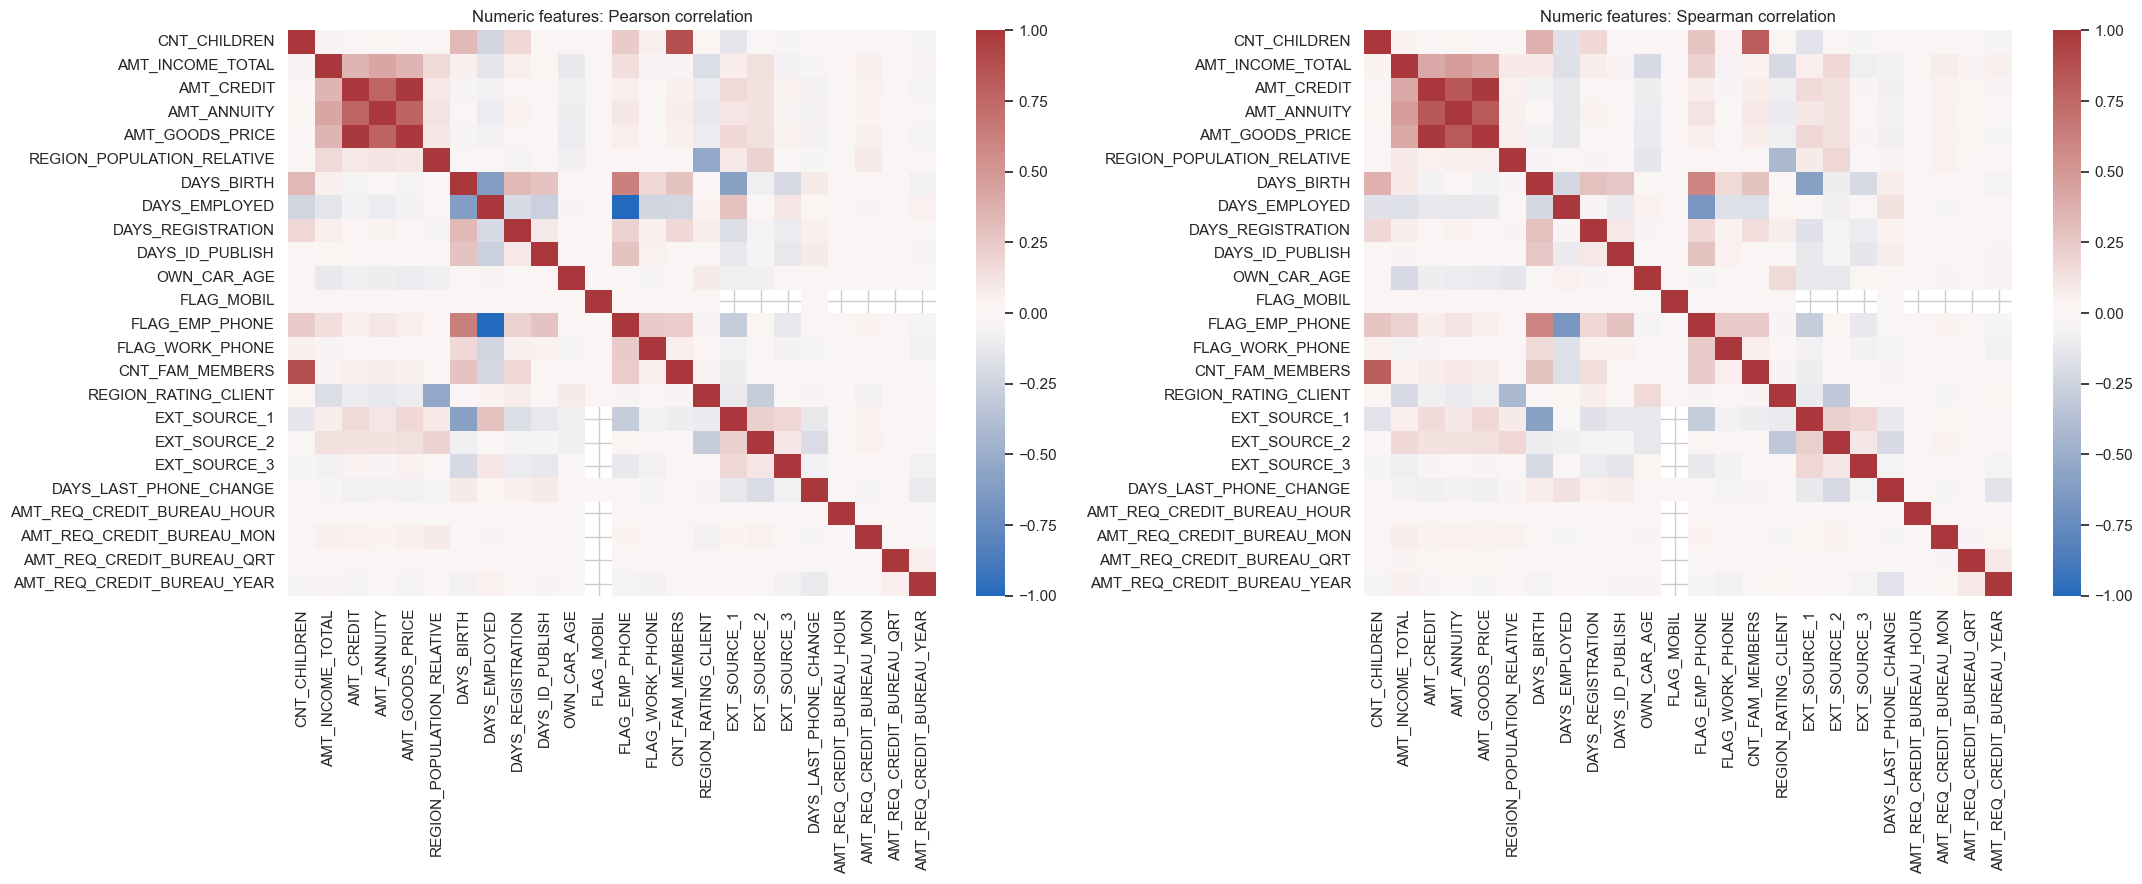

,pearson_with_target,spearman_with_target
EXT_SOURCE_3,-0.178317,-0.165889
EXT_SOURCE_1,-0.154050,-0.150163
EXT_SOURCE_2,-0.162562,-0.149300
DAYS_BIRTH,0.079541,0.079626
REGION_RATING_CLIENT,0.058984,0.058942
DAYS_ID_PUBLISH,0.052567,0.053583
OWN_CAR_AGE,0.040035,0.053487
DAYS_LAST_PHONE_CHANGE,0.055194,0.053387
FLAG_EMP_PHONE,0.045646,0.045646
DAYS_REGISTRATION,0.041669,0.040245


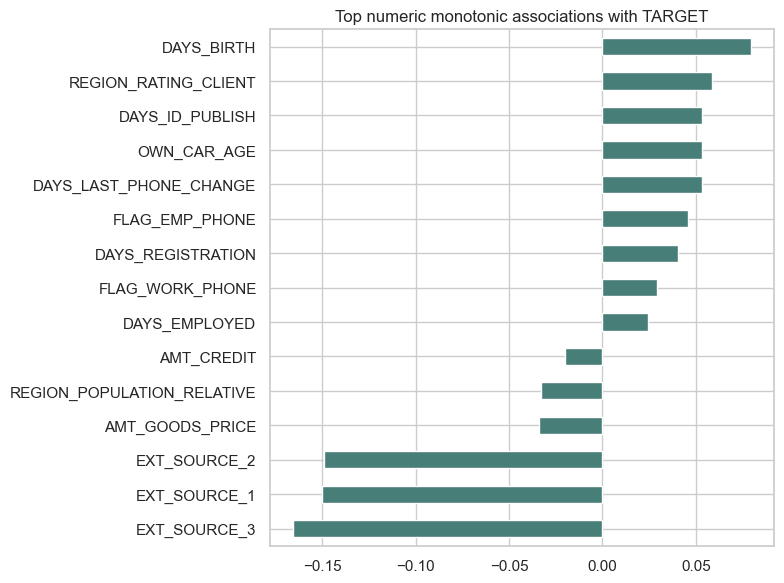

In [4]:
pearson_corr = X_raw[numeric_cols].corr(method='pearson')
spearman_corr = X_raw[numeric_cols].corr(method='spearman')
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(pearson_corr, cmap='vlag', center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Numeric features: Pearson correlation')
sns.heatmap(spearman_corr, cmap='vlag', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Numeric features: Spearman correlation')
plt.tight_layout(); plt.show()

target_association = pd.DataFrame({
    'pearson_with_target': X_raw[numeric_cols].corrwith(y, method='pearson'),
    'spearman_with_target': X_raw[numeric_cols].corrwith(y, method='spearman'),
}).sort_values('spearman_with_target', key=lambda s: s.abs(), ascending=False)
display(target_association)
fig, ax = plt.subplots(figsize=(8, 6))
target_association['spearman_with_target'].head(15).sort_values().plot.barh(ax=ax, color='#477e78')
ax.set_title('Top numeric monotonic associations with TARGET')
plt.tight_layout(); plt.show()

## 4. Categorical and Mixed-Type Associations

Cramér’s V summarizes categorical-to-categorical association, including each categorical feature against `TARGET`. The correlation ratio (η) summarizes numeric-to-categorical association. These measures let us inspect all feature-type combinations without pretending categories have numeric order.

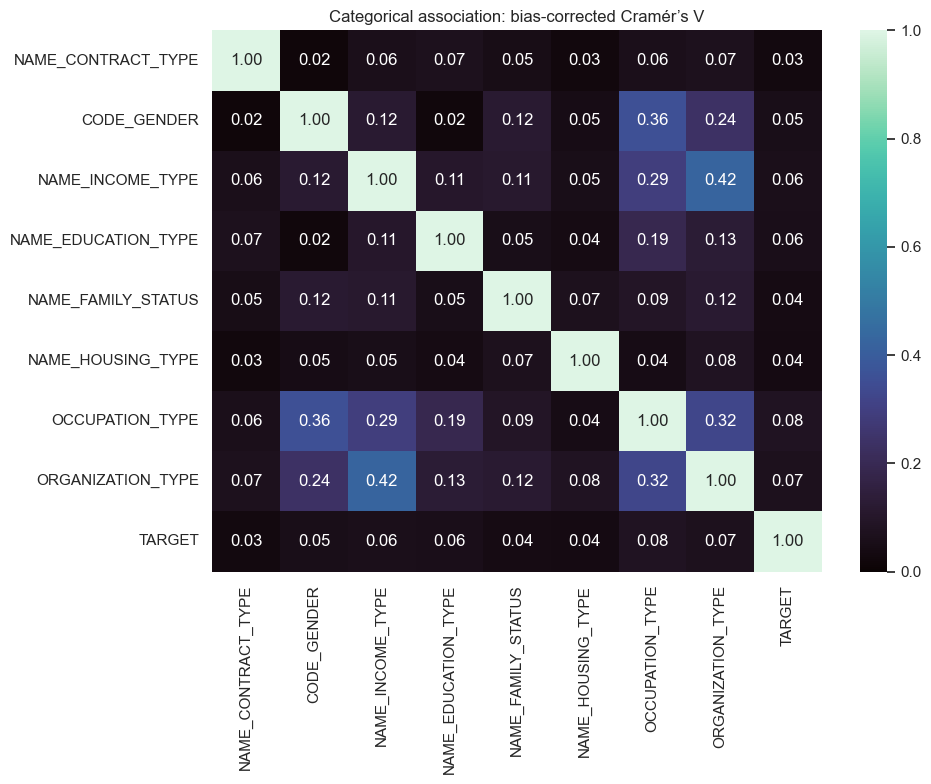

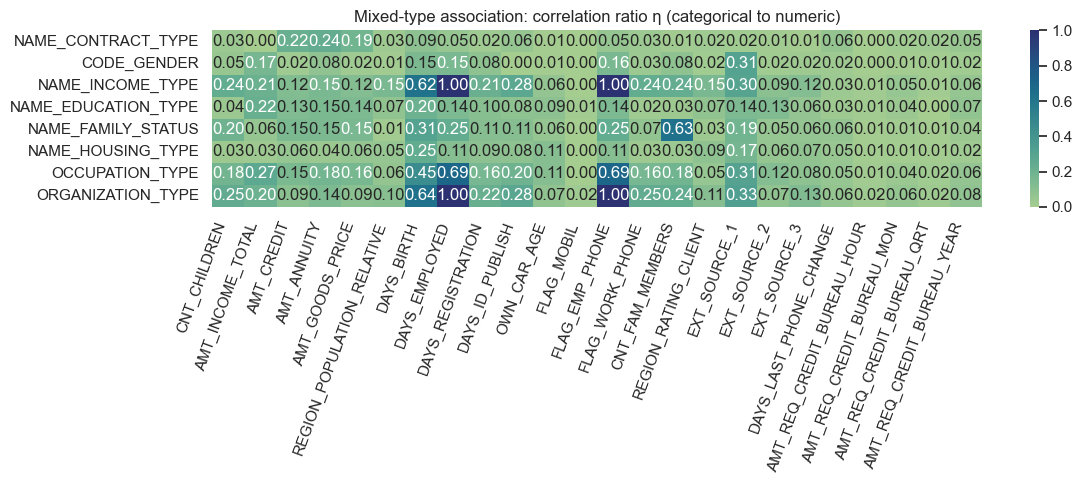

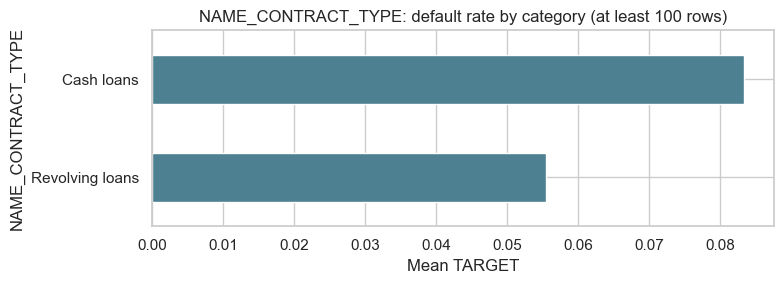

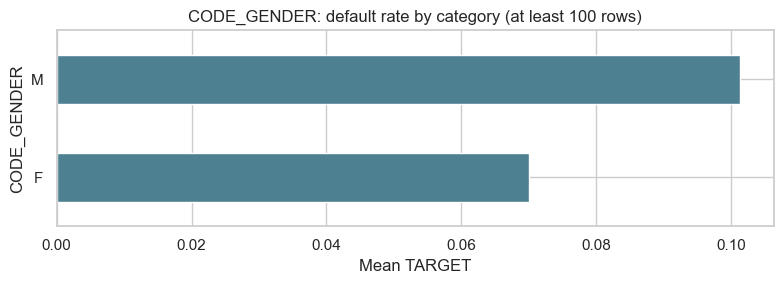

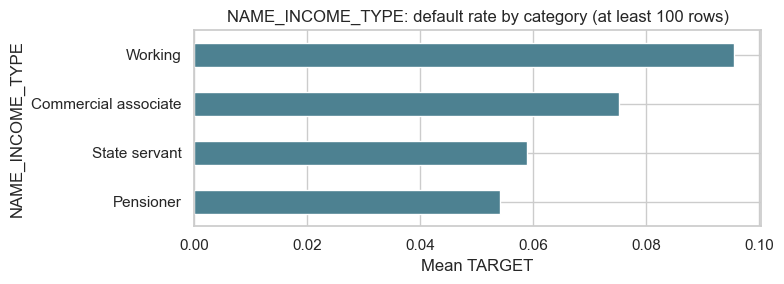

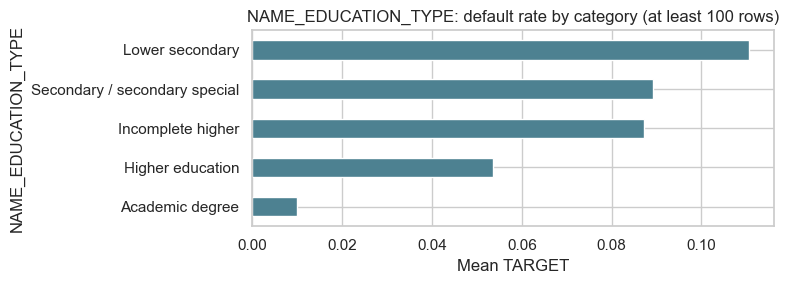

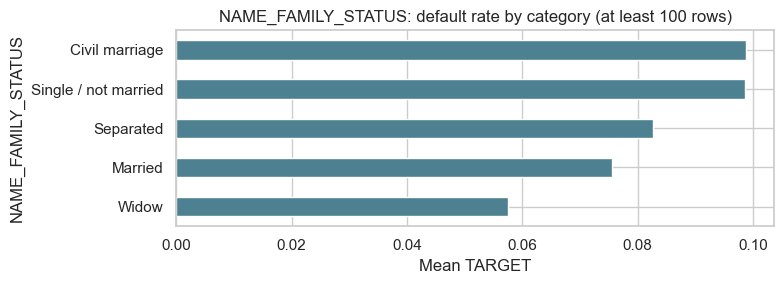

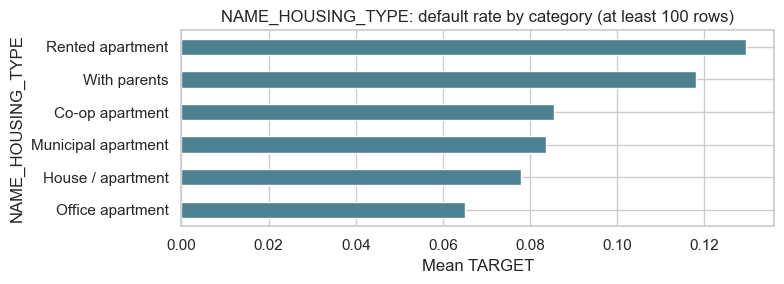

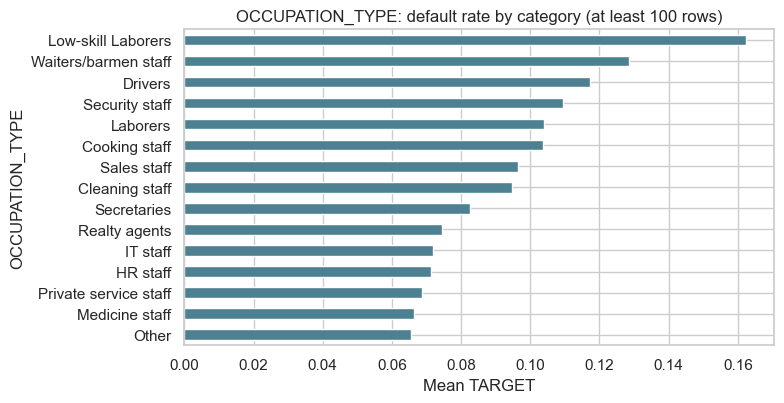

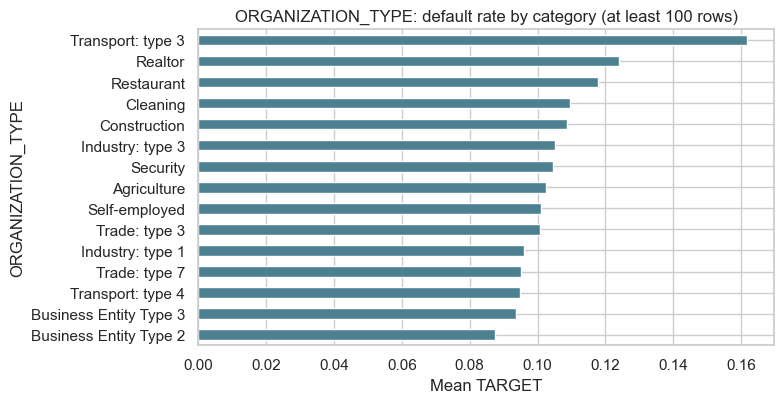

In [5]:
def cramers_v(left, right):
    table = pd.crosstab(left.fillna('__MISSING__'), right.fillna('__MISSING__'))
    if table.empty or min(table.shape) < 2:
        return 0.0
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    if n <= 1:
        return 0.0
    r, k = table.shape
    phi2 = chi2 / n
    phi2_corr = max(0.0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    denom = min(k_corr-1, r_corr-1)
    return float(np.sqrt(phi2_corr / denom)) if denom > 0 else 0.0

def correlation_ratio(categories, measurements):
    frame = pd.DataFrame({'category': categories.fillna('__MISSING__'), 'value': measurements})
    frame = frame.dropna(subset=['value'])
    if frame.empty or frame['category'].nunique() < 2:
        return 0.0
    overall_mean = frame['value'].mean()
    group_stats = frame.groupby('category', observed=False)['value'].agg(['mean','count'])
    between = (group_stats['count'] * (group_stats['mean']-overall_mean)**2).sum()
    total = ((frame['value']-overall_mean)**2).sum()
    return float(np.sqrt(between/total)) if total > 0 else 0.0

cat_with_target = categorical_cols + [TARGET_COL]
cramers_matrix = pd.DataFrame(index=cat_with_target, columns=cat_with_target, dtype=float)
for left in cat_with_target:
    for right in cat_with_target:
        cramers_matrix.loc[left,right] = 1.0 if left == right else cramers_v(train[left], train[right])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cramers_matrix, annot=True, fmt='.2f', cmap='mako', vmin=0, vmax=1, ax=ax)
ax.set_title('Categorical association: bias-corrected Cramér’s V')
plt.tight_layout(); plt.show()

eta_matrix = pd.DataFrame(index=categorical_cols, columns=numeric_cols, dtype=float)
for cat in categorical_cols:
    for num in numeric_cols:
        eta_matrix.loc[cat,num] = correlation_ratio(X_raw[cat], X_raw[num])
fig, ax = plt.subplots(figsize=(max(12, len(numeric_cols)*0.45), 5))
sns.heatmap(eta_matrix, annot=True, fmt='.2f', cmap='crest', vmin=0, vmax=1, ax=ax)
ax.set_title('Mixed-type association: correlation ratio η (categorical to numeric)')
plt.xticks(rotation=70, ha='right'); plt.tight_layout(); plt.show()

for col in categorical_cols:
    rates = train.groupby(col, dropna=False)[TARGET_COL].agg(['mean','count']).query('count >= 100').sort_values('mean').tail(15)
    fig, ax = plt.subplots(figsize=(8, max(3, len(rates)*0.28)))
    rates['mean'].plot.barh(ax=ax, color='#4d8191')
    ax.set_title(f'{col}: default rate by category (at least 100 rows)')
    ax.set_xlabel('Mean TARGET')
    plt.tight_layout(); plt.show()

## 5. Domain Feature Engineering

Create interpretable credit-risk features without removing rows or using `TARGET` as an input. Safe division leaves undefined ratios as missing for the imputer. The employment sentinel `DAYS_EMPLOYED = 365243` is marked separately and excluded from employment-duration calculations. These engineered features will flow into the preprocessing and encoding cells below.

In [6]:
def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def engineer_credit_features(frame):
    engineered = frame.copy()

    if 'DAYS_BIRTH' in engineered:
        engineered['AGE_YEARS'] = -engineered['DAYS_BIRTH'] / 365.25

    if 'DAYS_EMPLOYED' in engineered:
        is_employment_sentinel = engineered['DAYS_EMPLOYED'].eq(365243)
        valid_employment_days = engineered['DAYS_EMPLOYED'].mask(is_employment_sentinel)
        engineered['EMPLOYMENT_SENTINEL'] = is_employment_sentinel.astype('int8')
        engineered['EMPLOYED_YEARS'] = -valid_employment_days / 365.25
        if 'DAYS_BIRTH' in engineered:
            age_days = (-engineered['DAYS_BIRTH']).replace(0, np.nan)
            engineered['EMPLOYMENT_TO_AGE'] = -valid_employment_days / age_days

    for col in ['DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']:
        if col in engineered:
            engineered[f'{col}_YEARS_AGO'] = -engineered[col] / 365.25

    ratio_pairs = [
        ('AMT_CREDIT', 'AMT_INCOME_TOTAL'),
        ('AMT_ANNUITY', 'AMT_INCOME_TOTAL'),
        ('AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL'),
        ('AMT_ANNUITY', 'AMT_CREDIT'),
        ('AMT_GOODS_PRICE', 'AMT_CREDIT'),
        ('AMT_CREDIT', 'CNT_FAM_MEMBERS'),
        ('AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS'),
    ]
    for numerator, denominator in ratio_pairs:
        if numerator in engineered and denominator in engineered:
            engineered[f'{numerator}_PER_{denominator}'] = safe_divide(
                engineered[numerator], engineered[denominator]
            )

    if {'AMT_INCOME_TOTAL', 'CNT_CHILDREN'}.issubset(engineered.columns):
        engineered['INCOME_PER_CHILD'] = safe_divide(
            engineered['AMT_INCOME_TOTAL'], engineered['CNT_CHILDREN']
        )

    score_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in engineered]
    if score_cols:
        engineered['EXT_SOURCE_MEAN'] = engineered[score_cols].mean(axis=1)
        engineered['EXT_SOURCE_STD'] = engineered[score_cols].std(axis=1)
        engineered['EXT_SOURCE_MIN'] = engineered[score_cols].min(axis=1)
        engineered['EXT_SOURCE_MAX'] = engineered[score_cols].max(axis=1)
        engineered['EXT_SOURCE_AVAILABLE'] = engineered[score_cols].notna().sum(axis=1)
        for i, left in enumerate(score_cols):
            for right in score_cols[i + 1:]:
                engineered[f'{left}_X_{right}'] = engineered[left] * engineered[right]
                engineered[f'{left}_MINUS_{right}'] = engineered[left] - engineered[right]

    bureau_cols = [c for c in engineered if c.startswith('AMT_REQ_CREDIT_BUREAU_')]
    if bureau_cols:
        engineered['BUREAU_REQUESTS_SUM'] = engineered[bureau_cols].sum(axis=1, min_count=1)
        engineered['BUREAU_REQUESTS_NONZERO'] = (engineered[bureau_cols].fillna(0) > 0).sum(axis=1)
        engineered['BUREAU_REQUESTS_MISSING'] = engineered[bureau_cols].isna().sum(axis=1)

    engineered['ROW_MISSING_COUNT'] = engineered.isna().sum(axis=1)
    return engineered


X_raw_base = X_raw.copy()
X_test_raw_base = X_test_raw.copy()
X_raw = engineer_credit_features(X_raw_base)
X_test_raw = engineer_credit_features(X_test_raw_base)
numeric_cols = X_raw.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_raw.select_dtypes(exclude=np.number).columns.tolist()
engineered_cols = [col for col in X_raw.columns if col not in X_raw_base.columns]

print('Engineered feature count:', len(engineered_cols))
print('Engineered fields:', engineered_cols)
assert len(X_raw) == train_rows_before
assert len(X_test_raw) == test_rows_before
assert TARGET_COL not in X_raw.columns and ID_COL not in X_raw.columns

Engineered feature count: 30
Engineered fields: ['AGE_YEARS', 'EMPLOYMENT_SENTINEL', 'EMPLOYED_YEARS', 'EMPLOYMENT_TO_AGE', 'DAYS_REGISTRATION_YEARS_AGO', 'DAYS_ID_PUBLISH_YEARS_AGO', 'DAYS_LAST_PHONE_CHANGE_YEARS_AGO', 'AMT_CREDIT_PER_AMT_INCOME_TOTAL', 'AMT_ANNUITY_PER_AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE_PER_AMT_INCOME_TOTAL', 'AMT_ANNUITY_PER_AMT_CREDIT', 'AMT_GOODS_PRICE_PER_AMT_CREDIT', 'AMT_CREDIT_PER_CNT_FAM_MEMBERS', 'AMT_INCOME_TOTAL_PER_CNT_FAM_MEMBERS', 'INCOME_PER_CHILD', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_AVAILABLE', 'EXT_SOURCE_1_X_EXT_SOURCE_2', 'EXT_SOURCE_1_MINUS_EXT_SOURCE_2', 'EXT_SOURCE_1_X_EXT_SOURCE_3', 'EXT_SOURCE_1_MINUS_EXT_SOURCE_3', 'EXT_SOURCE_2_X_EXT_SOURCE_3', 'EXT_SOURCE_2_MINUS_EXT_SOURCE_3', 'BUREAU_REQUESTS_SUM', 'BUREAU_REQUESTS_NONZERO', 'BUREAU_REQUESTS_MISSING', 'ROW_MISSING_COUNT']


### Engineered DataFrame Preview and Summary

Inspect example rows and descriptive statistics for the engineered fields. `TARGET` is shown only for EDA and is not part of `X_raw` or `X_test_raw`.

,AGE_YEARS,EMPLOYMENT_SENTINEL,EMPLOYED_YEARS,EMPLOYMENT_TO_AGE,DAYS_REGISTRATION_YEARS_AGO,DAYS_ID_PUBLISH_YEARS_AGO,DAYS_LAST_PHONE_CHANGE_YEARS_AGO,AMT_CREDIT_PER_AMT_INCOME_TOTAL,AMT_ANNUITY_PER_AMT_INCOME_TOTAL,AMT_GOODS_PRICE_PER_AMT_INCOME_TOTAL,...,EXT_SOURCE_1_X_EXT_SOURCE_2,EXT_SOURCE_1_MINUS_EXT_SOURCE_2,EXT_SOURCE_1_X_EXT_SOURCE_3,EXT_SOURCE_1_MINUS_EXT_SOURCE_3,EXT_SOURCE_2_X_EXT_SOURCE_3,EXT_SOURCE_2_MINUS_EXT_SOURCE_3,BUREAU_REQUESTS_SUM,BUREAU_REQUESTS_NONZERO,BUREAU_REQUESTS_MISSING,ROW_MISSING_COUNT
0,25.278576,0,2.403833,0.095094,0.911704,1.429158,0.799452,6.712800,0.322920,6.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4,16
1,55.162218,1,NaN,NaN,12.235455,9.407255,1.689254,2.600000,0.075080,2.600000,...,NaN,NaN,NaN,NaN,0.248685,-0.103598,1.0,1,0,9
2,50.639288,0,1.431896,0.028276,9.965777,5.612594,1.483915,6.188000,0.338083,5.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4,16
3,66.193018,1,NaN,NaN,13.552361,10.817248,-0.000000,2.264000,0.131867,2.000000,...,NaN,NaN,NaN,NaN,0.080770,-0.662289,0.0,0,0,9
4,29.253936,0,1.908282,0.065232,13.965777,8.832307,3.403149,1.721057,0.136800,1.485714,...,0.069321,0.139854,0.229048,-0.326713,0.135477,-0.466567,4.0,1,0,2
5,45.982204,0,1.163587,0.025305,7.655031,0.887064,0.840520,1.833333,0.147933,1.833333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4,16
6,39.750856,0,11.195072,0.281631,22.203970,15.055441,5.251198,1.761619,0.090619,1.261905,...,NaN,NaN,NaN,NaN,0.262989,0.258329,3.0,1,0,7
7,23.611225,0,1.037645,0.043947,4.908966,3.263518,-0.000000,1.293714,0.154343,1.142857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4,16
8,40.010951,0,1.675565,0.041878,14.064339,11.060917,0.002738,2.495833,0.068625,2.083333,...,NaN,NaN,NaN,NaN,0.445732,0.078203,0.0,0,0,5
9,48.197125,0,14.902122,0.309191,1.245722,2.507871,2.477755,1.150650,0.091625,0.950000,...,0.141192,0.232716,NaN,NaN,NaN,NaN,NaN,0,4,11


,count,mean,std,min,1%,25%,50%,75%,99%,max
AGE_YEARS,171202.0,43.929748,11.947412,2.100753e+01,22.603696,34.004107,43.197810,53.897331,6.681448e+01,6.907324e+01
EMPLOYMENT_SENTINEL,171202.0,0.180477,0.384585,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
EMPLOYED_YEARS,140304.0,6.539584,6.397166,2.737851e-03,0.303901,2.110883,4.517454,8.739220,3.091573e+01,4.904038e+01
EMPLOYMENT_TO_AGE,140304.0,0.157084,0.133467,4.202034e-05,0.007508,0.056252,0.118787,0.219661,5.896114e-01,7.288115e-01
DAYS_REGISTRATION_YEARS_AGO,171202.0,13.675517,9.653005,-0.000000e+00,0.136893,5.497604,12.361396,20.506502,3.803959e+01,6.754825e+01
DAYS_ID_PUBLISH_YEARS_AGO,171202.0,8.187504,4.133317,0.000000e+00,0.164271,4.693361,8.889802,11.764545,1.489665e+01,1.970431e+01
DAYS_LAST_PHONE_CHANGE_YEARS_AGO,171202.0,2.634929,2.262224,-0.000000e+00,0.000000,0.750171,2.072553,4.292950,8.643395e+00,1.142505e+01
AMT_CREDIT_PER_AMT_INCOME_TOTAL,171202.0,3.958324,2.688714,6.666667e-02,0.589149,2.018667,3.267273,5.166133,1.304256e+01,4.922720e+01
AMT_ANNUITY_PER_AMT_INCOME_TOTAL,171202.0,0.181042,0.094628,3.333333e-03,0.039115,0.114784,0.162961,0.229300,4.839000e-01,1.570600e+00
AMT_GOODS_PRICE_PER_AMT_INCOME_TOTAL,171202.0,3.542867,2.423157,6.666667e-02,0.525000,1.840000,2.940000,4.615385,1.194116e+01,4.400000e+01


Missing values in engineered features:


,missing_count
EXT_SOURCE_1_MINUS_EXT_SOURCE_3,134980
EXT_SOURCE_1_X_EXT_SOURCE_3,134980
INCOME_PER_CHILD,119950
EXT_SOURCE_1_X_EXT_SOURCE_2,119015
EXT_SOURCE_1_MINUS_EXT_SOURCE_2,119015
EXT_SOURCE_2_MINUS_EXT_SOURCE_3,54809
EXT_SOURCE_2_X_EXT_SOURCE_3,54809
EXT_SOURCE_STD,38728
EMPLOYED_YEARS,30898
EMPLOYMENT_TO_AGE,30898


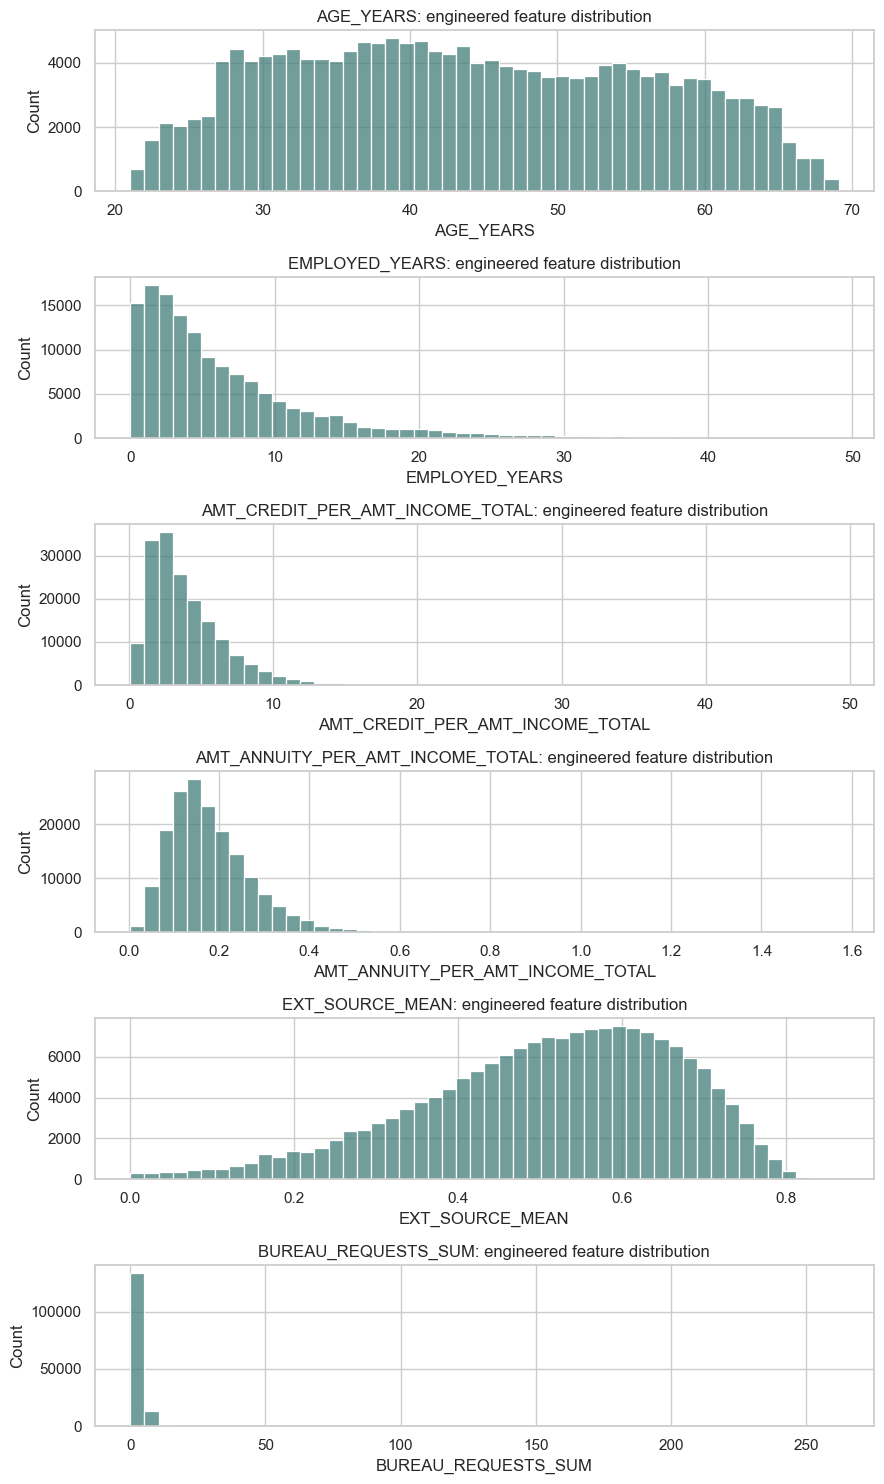

In [7]:
display(X_raw[engineered_cols].head(10))

engineered_description = X_raw[engineered_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
display(engineered_description)

print('Missing values in engineered features:')
display(X_raw[engineered_cols].isna().sum().sort_values(ascending=False).rename('missing_count').to_frame())

describe_plot_cols = [col for col in [
    'AGE_YEARS', 'EMPLOYED_YEARS', 'AMT_CREDIT_PER_AMT_INCOME_TOTAL',
    'AMT_ANNUITY_PER_AMT_INCOME_TOTAL', 'EXT_SOURCE_MEAN',
    'INCOME_PER_FAMILY_MEMBER', 'BUREAU_REQUESTS_SUM'
] if col in X_raw]
fig, axes = plt.subplots(len(describe_plot_cols), 1, figsize=(9, max(3, 2.5 * len(describe_plot_cols))))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, describe_plot_cols):
    sns.histplot(data=X_raw, x=col, bins=50, ax=ax, color='#417d79')
    ax.set_title(f'{col}: engineered feature distribution')
plt.tight_layout(); plt.show()

### Engineered Features and Outcome Relationships

These graphs show how the new fields vary with default outcome. For highly skewed quantities, the displayed axes are limited to the training 1st–99th percentiles for readability; no observations are filtered from `X_raw`, `X_test_raw`, imputation, or encoding.

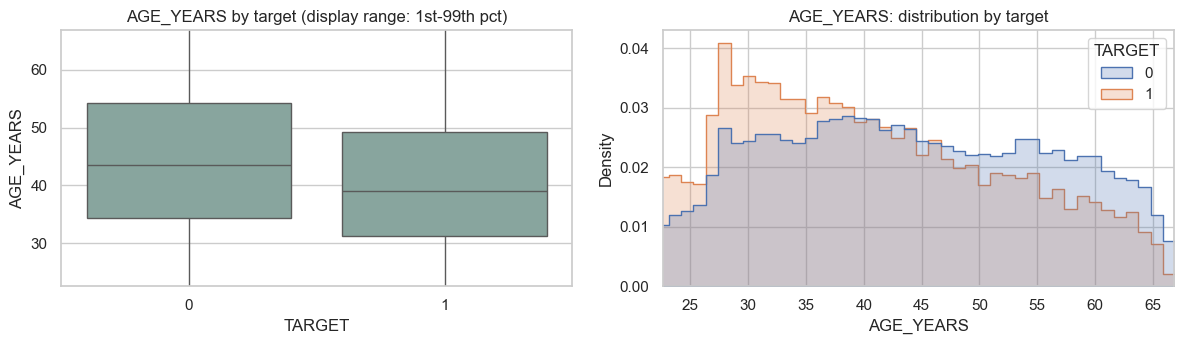

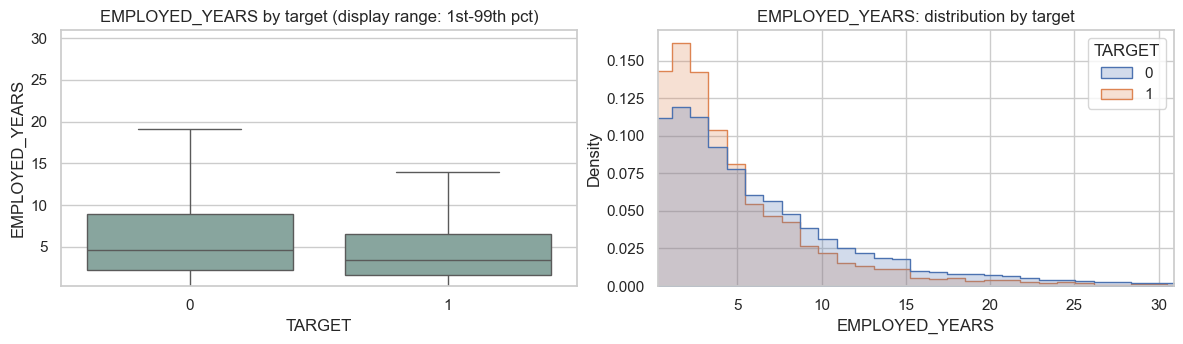

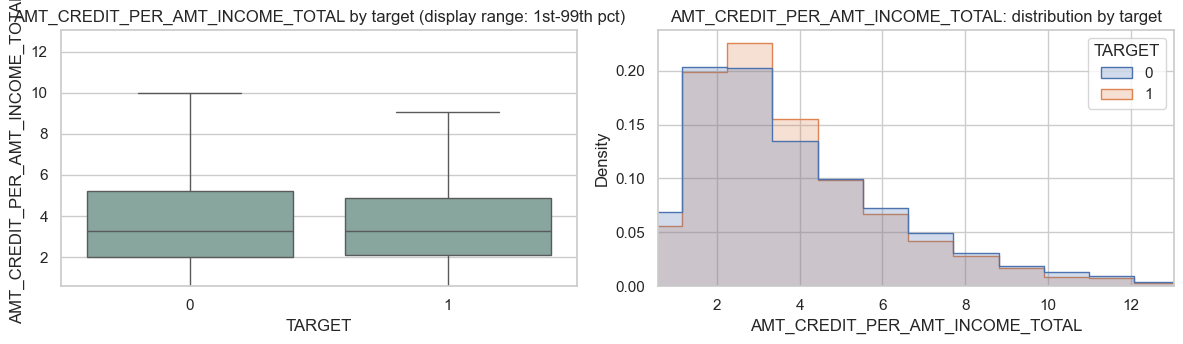

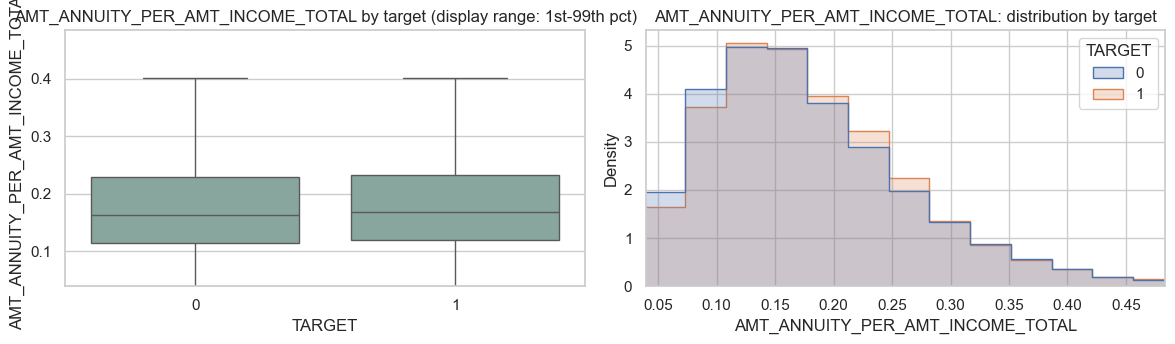

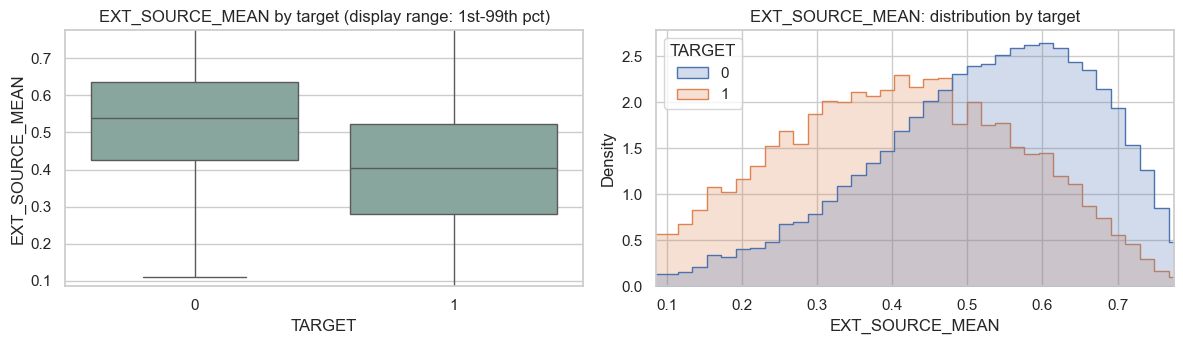

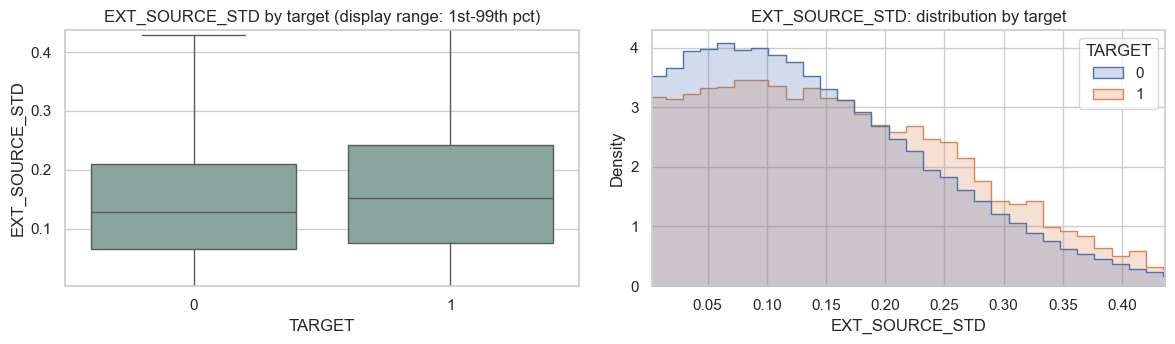

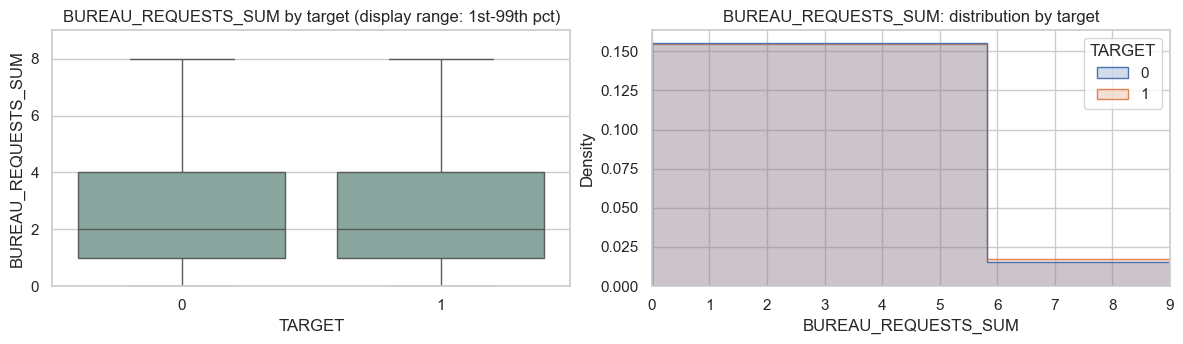

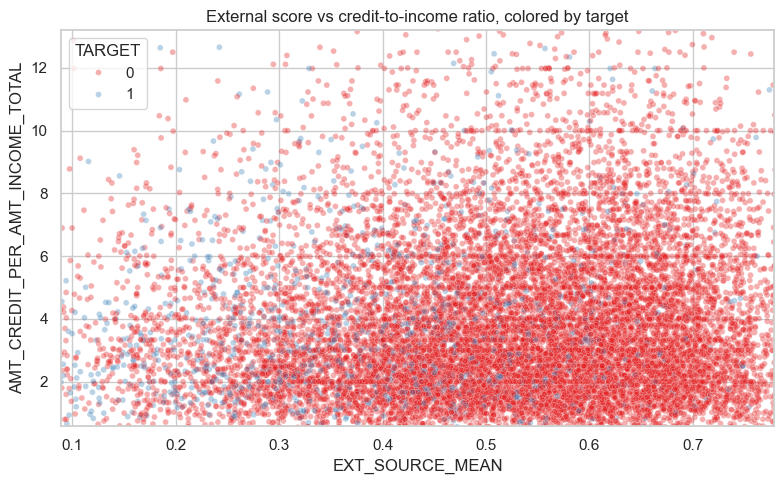

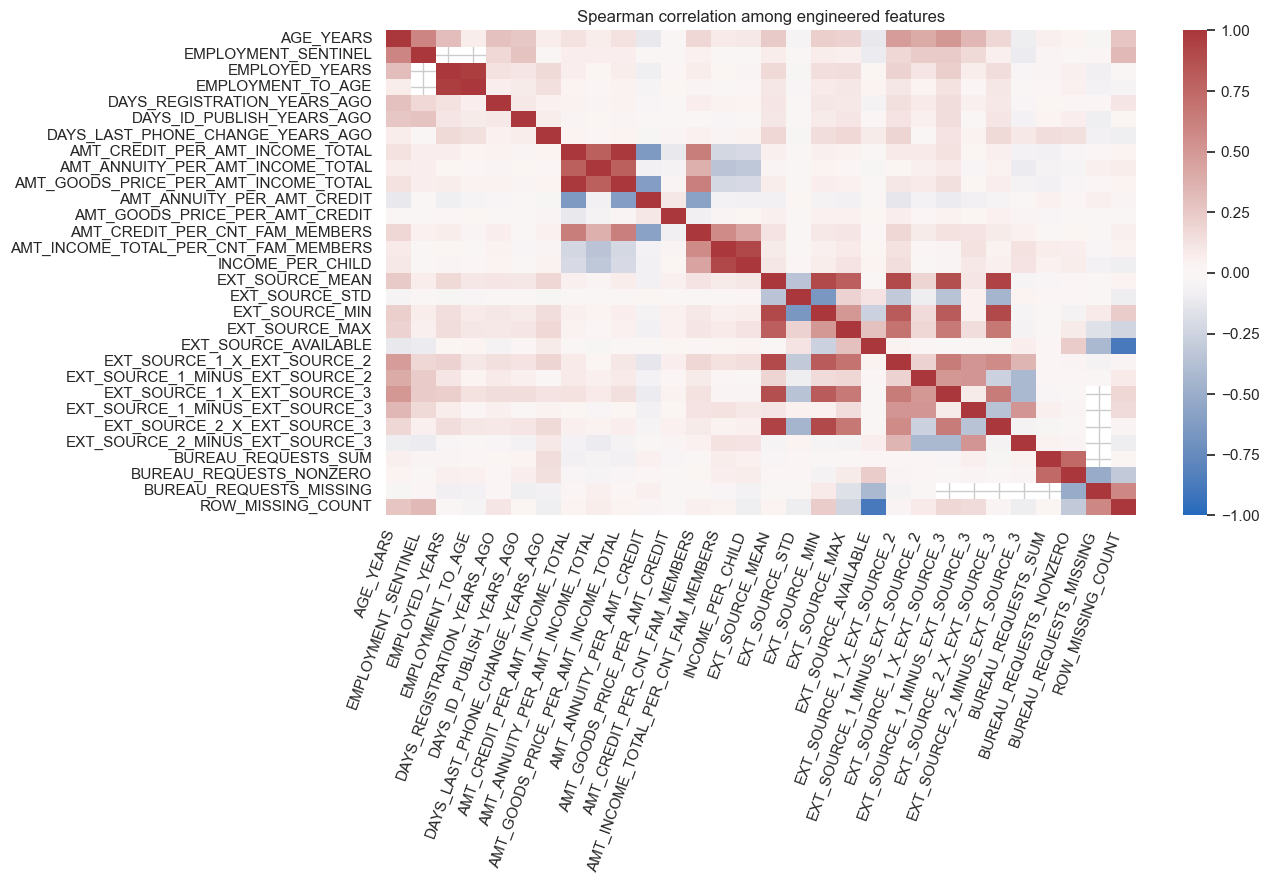

In [8]:
relationship_cols = [col for col in [
    'AGE_YEARS', 'EMPLOYED_YEARS', 'AMT_CREDIT_PER_AMT_INCOME_TOTAL',
    'AMT_ANNUITY_PER_AMT_INCOME_TOTAL', 'INCOME_PER_FAMILY_MEMBER',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'BUREAU_REQUESTS_SUM'
] if col in X_raw]

for col in relationship_cols:
    plot_frame = pd.DataFrame({col: X_raw[col], TARGET_COL: y})
    lower, upper = plot_frame[col].quantile([0.01, 0.99])
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    sns.boxplot(data=plot_frame, x=TARGET_COL, y=col, showfliers=False, ax=axes[0], color='#83aaa1')
    axes[0].set_ylim(lower, upper)
    axes[0].set_title(f'{col} by target (display range: 1st-99th pct)')
    sns.histplot(data=plot_frame, x=col, hue=TARGET_COL, bins=45, stat='density',
                 common_norm=False, element='step', ax=axes[1])
    axes[1].set_xlim(lower, upper)
    axes[1].set_title(f'{col}: distribution by target')
    plt.tight_layout(); plt.show()

if {'EXT_SOURCE_MEAN', 'AMT_CREDIT_PER_AMT_INCOME_TOTAL'}.issubset(X_raw.columns):
    scatter_cols = ['EXT_SOURCE_MEAN', 'AMT_CREDIT_PER_AMT_INCOME_TOTAL']
    scatter_frame = X_raw[scatter_cols].copy()
    scatter_frame[TARGET_COL] = y
    scatter_frame = scatter_frame.sample(n=min(15000, len(scatter_frame)), random_state=RANDOM_SEED)
    x_low, x_high = scatter_frame[scatter_cols[0]].quantile([0.01, 0.99])
    y_low, y_high = scatter_frame[scatter_cols[1]].quantile([0.01, 0.99])
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=scatter_frame, x=scatter_cols[0], y=scatter_cols[1], hue=TARGET_COL,
                    alpha=0.35, s=18, ax=ax, palette='Set1')
    ax.set_xlim(x_low, x_high); ax.set_ylim(y_low, y_high)
    ax.set_title('External score vs credit-to-income ratio, colored by target')
    plt.tight_layout(); plt.show()

engineered_numeric = [col for col in engineered_cols if pd.api.types.is_numeric_dtype(X_raw[col])]
if len(engineered_numeric) > 1:
    engineered_corr = X_raw[engineered_numeric].corr(method='spearman')
    fig, ax = plt.subplots(figsize=(max(10, len(engineered_numeric)*0.45), 9))
    sns.heatmap(engineered_corr, cmap='vlag', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title('Spearman correlation among engineered features')
    plt.xticks(rotation=70, ha='right'); plt.tight_layout(); plt.show()

## 5. Choose Missing-Value Replacements

Numeric predictors use the **training median**: it is robust to skew and the outliers just counted. A missingness indicator is added by the imputer. Categorical predictors use a dedicated `__MISSING__` category rather than the mode, so missingness remains visible to the model. The imputer/encoder is fitted on training data only. This stage does not clip outliers or discard rows.

In [12]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='__MISSING__')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numeric_cols),
        ('categorical', categorical_pipeline, categorical_cols),
    ],
    remainder='drop',
    sparse_threshold=1.0,
)

X_train_encoded = preprocessor.fit_transform(X_raw)
X_test_encoded = preprocessor.transform(X_test_raw)
encoded_feature_names = preprocessor.get_feature_names_out()

print('Encoded train shape:', X_train_encoded.shape)
print('Encoded test shape:', X_test_encoded.shape)
print('Encoded data is sparse:', sparse.issparse(X_train_encoded))
print('Rows preserved:', X_train_encoded.shape[0] == train_rows_before, X_test_encoded.shape[0] == test_rows_before)
print('Features encoded:', len(encoded_feature_names))
assert X_train_encoded.shape[0] == train_rows_before
assert X_test_encoded.shape[0] == test_rows_before
assert len(encoded_feature_names) == X_train_encoded.shape[1] == X_test_encoded.shape[1]

Encoded train shape: (171202, 140)
Encoded test shape: (61500, 140)
Encoded data is sparse: True
Rows preserved: True True
Features encoded: 140


## 6. Correlations Across All Encoded Features

The next heatmap includes every numeric predictor and every one-hot indicator. It computes correlations from sparse matrix products, so the full encoded matrix does not need to be densified. One-hot columns are binary indicators; their correlations describe co-occurrence/association, not ordered category values.

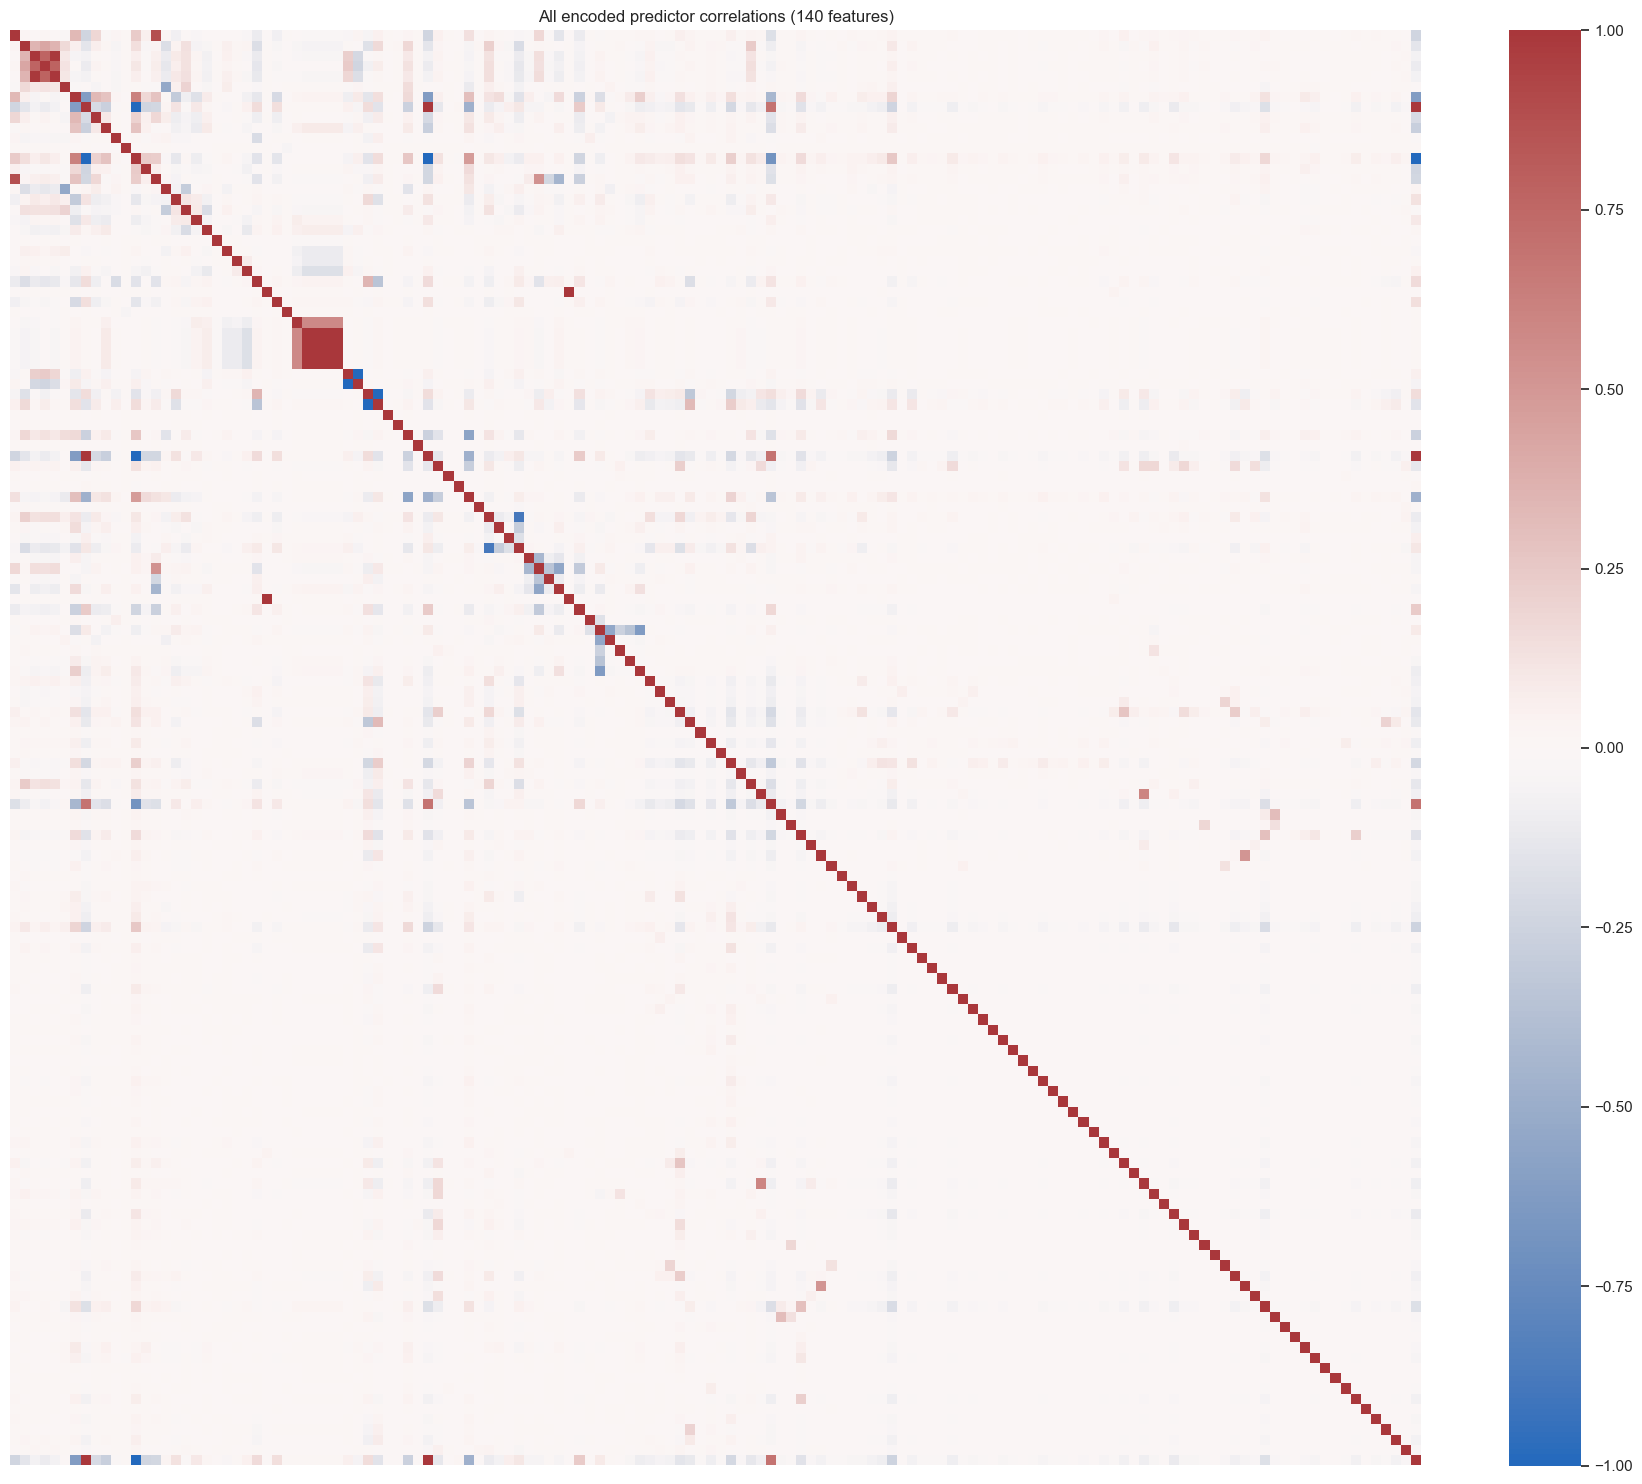

correlation  \
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...     1.000000   
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...     1.000000   
categorical__NAME_CONTRACT_TYPE_Cash loans         categorical__NAME_CONTRACT_TYPE_Revolving loans       -1.000000   
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...     1.000000   
                                                   numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...     1.000000   
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...     1.000000   
numeric__missingindicator_CNT_FAM_MEMBERS          categorical__NAME_FAMILY_STATUS_Unknown                1.000000   
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...     1.000000   
categorical__CODE_GENDER_F                         categorical__CODE_GENDER_M                            -0.999948   
numeric__FLAG_EMP_PHONE                            categorical__ORGANIZATION_TYPE_XNA                    -0.999901   
numeric__DAYS_EMPLOYED                             categorical__ORGANIZATION_TYPE_XNA                     0.999888   
                                                   numeric__FLAG_EMP_PHONE                               -0.999789   
categorical__NAME_INCOME_TYPE_Pensioner            categorical__ORGANIZATION_TYPE_XNA                     0.999664   
numeric__FLAG_EMP_PHONE                            categorical__NAME_INCOME_TYPE_Pensioner               -0.999566   
numeric__DAYS_EMPLOYED                             categorical__NAME_INCOME_TYPE_Pensioner                0.999551   
numeric__AMT_CREDIT                                numeric__AMT_GOODS_PRICE                               0.986584   
categorical__NAME_EDUCATION_TYPE_Higher education  categorical__NAME_EDUCATION_TYPE_Secondary / se...    -0.887855   
numeric__CNT_CHILDREN                              numeric__CNT_FAM_MEMBERS                               0.878705   
numeric__AMT_ANNUITY                               numeric__AMT_GOODS_PRICE                               0.776489   
numeric__AMT_CREDIT                                numeric__AMT_ANNUITY                                   0.771588   
categorical__OCCUPATION_TYPE_Other                 categorical__ORGANIZATION_TYPE_XNA                     0.693713   
numeric__FLAG_EMP_PHONE                            categorical__OCCUPATION_TYPE_Other                    -0.693684   
categorical__NAME_INCOME_TYPE_Pensioner            categorical__OCCUPATION_TYPE_Other                     0.693607   
numeric__DAYS_EMPLOYED                             categorical__OCCUPATION_TYPE_Other                     0.693597   
categorical__NAME_HOUSING_TYPE_House / apartment   categorical__NAME_HOUSING_TYPE_With parents           -0.632029   

                                                                                                       abs_correlation  
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...         1.000000  
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...         1.000000  
categorical__NAME_CONTRACT_TYPE_Cash loans         categorical__NAME_CONTRACT_TYPE_Revolving loans            1.000000  
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...         1.000000  
                                                   numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...         1.000000  
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missingindicator_AMT_REQ_CREDIT_BUREAU...         1.000000  
numeric__missingindicator_CNT_FAM_MEMBERS          categorical__NAME_FAMILY_STATUS_Unknown                    1.000000  
numeric__missingindicator_AMT_REQ_CREDIT_BUREAU... numeric__missin

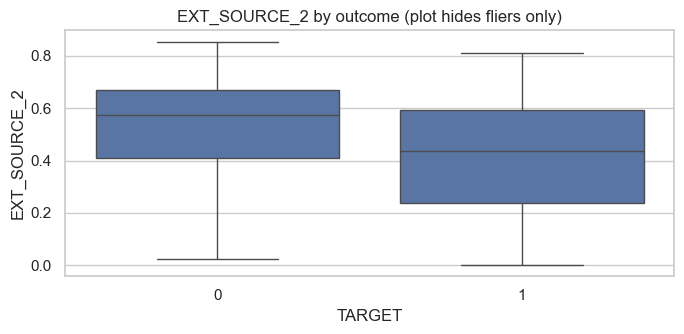

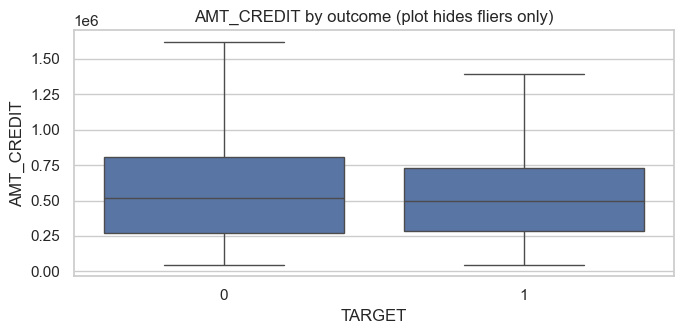

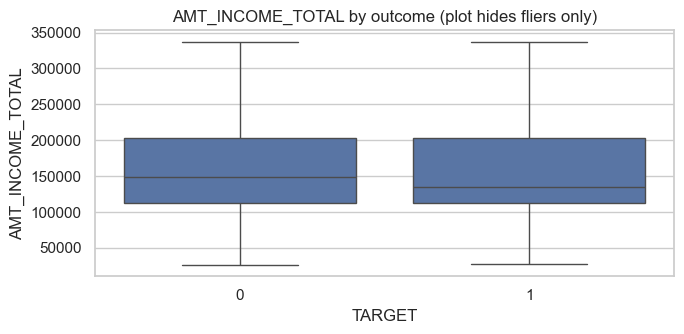

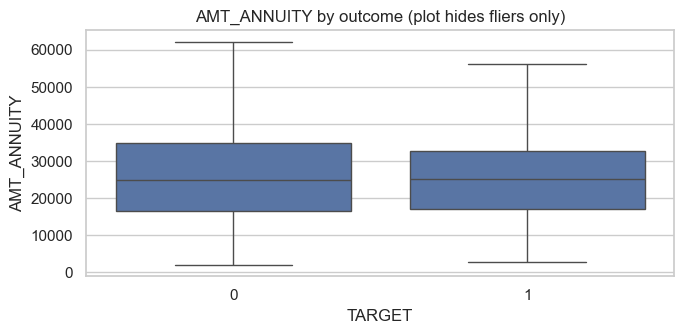

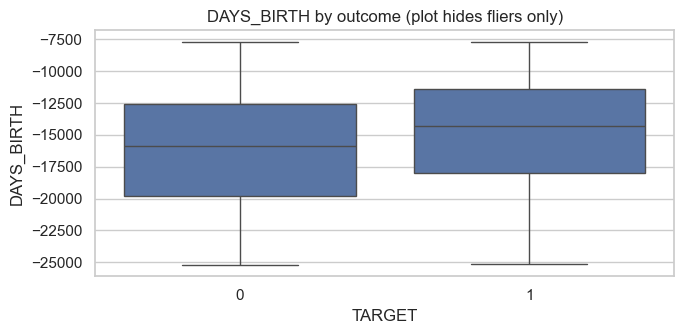

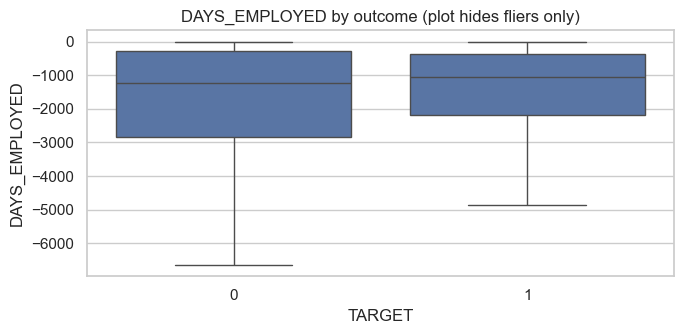

Completed: no rows dropped, no outliers clipped, no predictors removed.


In [17]:
def sparse_correlation_matrix(matrix):
    n_rows = matrix.shape[0]
    means = np.asarray(matrix.mean(axis=0)).ravel()
    second_moment = (matrix.multiply(matrix).sum(axis=0) / n_rows).A1 if sparse.issparse(matrix) else np.mean(matrix**2, axis=0)
    cross_moment = (matrix.T @ matrix).toarray() / n_rows if sparse.issparse(matrix) else (matrix.T @ matrix) / n_rows
    covariance = cross_moment - np.outer(means, means)
    variances = np.maximum(second_moment - means**2, 0)
    denom = np.sqrt(np.outer(variances, variances))
    corr = np.divide(covariance, denom, out=np.zeros_like(covariance), where=denom > 0)
    np.fill_diagonal(corr, 1.0)
    return np.clip(corr, -1, 1)

encoded_corr = sparse_correlation_matrix(X_train_encoded)
encoded_corr_df = pd.DataFrame(encoded_corr, index=encoded_feature_names, columns=encoded_feature_names)
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(encoded_corr_df, cmap='vlag', center=0, vmin=-1, vmax=1, xticklabels=False, yticklabels=False, ax=ax)
ax.set_title(f'All encoded predictor correlations ({len(encoded_feature_names)} features)')
plt.tight_layout(); plt.show()

upper = encoded_corr_df.where(np.triu(np.ones(encoded_corr_df.shape), k=1).astype(bool))
strong_pairs = upper.stack().rename('correlation').to_frame()
strong_pairs['abs_correlation'] = strong_pairs['correlation'].abs()
display(strong_pairs.sort_values('abs_correlation', ascending=False).head(25))

# Example numeric feature distributions by outcome, without filtering any records.
plot_cols = [c for c in ['EXT_SOURCE_2','AMT_CREDIT','AMT_INCOME_TOTAL','AMT_ANNUITY','DAYS_BIRTH','DAYS_EMPLOYED'] if c in X_raw]
for col in plot_cols:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.boxplot(data=train, x=TARGET_COL, y=col, showfliers=False, ax=ax)
    ax.set_title(f'{col} by outcome (plot hides fliers only)')
    plt.tight_layout(); plt.show()

assert len(train) == train_rows_before and len(test) == test_rows_before
print('Completed: no rows dropped, no outliers clipped, no predictors removed.')

# XGBoost Baseline, Feature Review, and ROC-AUC Tuning

This notebook builds on the EDA. It keeps rows and source features, adds domain features, evaluates a baseline, tunes XGBoost with stratified folds, and reports a separate stratified holdout score. Preprocessing is fitted inside each CV fold.

The supplied correlation table identifies redundancy, not which feature predicts default best. Perfect correlations among one-hot complements or shared missingness flags are expected; keep them for the baseline and use validation/importance for feature decisions. The competition metric is ROC-AUC, so use probability scores and do not tune a classification threshold.

In [18]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

SEED = 42
HOLDOUT_SIZE = 0.20
CV_SPLITS = 3
SEARCH_ITERATIONS = 8
MAKE_SUBMISSION = False
ID_COL = 'SK_ID_CURR'
TARGET_COL = 'TARGET'

def find_data_root():
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / 'input' / 'train.csv').is_file():
            return folder
    raise FileNotFoundError('Could not find input/train.csv from this notebook directory.')

DATA_ROOT = find_data_root()
train = pd.read_csv(DATA_ROOT / 'input' / 'train.csv')
test = pd.read_csv(DATA_ROOT / 'input' / 'test.csv')
sample_submission = pd.read_csv(DATA_ROOT / 'input' / 'sample_submission.csv')
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert train[TARGET_COL].isin([0, 1]).all()
assert [c for c in train.columns if c != TARGET_COL] == test.columns.tolist()
assert sample_submission.columns.tolist() == [ID_COL, TARGET_COL]
assert sample_submission[ID_COL].equals(test[ID_COL])
print('train:', train.shape, '| test:', test.shape, '| default rate:', round(train[TARGET_COL].mean(), 5))
print('XGBoost:', XGBClassifier().get_xgb_params().get('tree_method', 'default'))

train: (171202, 34) | test: (61500, 33) | default rate: 0.08073
XGBoost: None


## 1. Feature Engineering

Features are computed row-by-row and identically for train and test. The employment sentinel is flagged rather than interpreted as a real duration. No observations are removed or capped.

In [19]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)

def engineer_features(frame):
    result = frame.copy()
    if 'DAYS_BIRTH' in result:
        result['AGE_YEARS'] = -result['DAYS_BIRTH'] / 365.25
    if 'DAYS_EMPLOYED' in result:
        sentinel = result['DAYS_EMPLOYED'].eq(365243)
        employment_days = result['DAYS_EMPLOYED'].mask(sentinel)
        result['EMPLOYMENT_SENTINEL'] = sentinel.astype('int8')
        result['EMPLOYED_YEARS'] = -employment_days / 365.25
        if 'DAYS_BIRTH' in result:
            age_days = (-result['DAYS_BIRTH']).replace(0, np.nan)
            result['EMPLOYMENT_TO_AGE'] = -employment_days / age_days
    for col in ['DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']:
        if col in result:
            result[f'{col}_YEARS_AGO'] = -result[col] / 365.25

    ratios = [
        ('AMT_CREDIT', 'AMT_INCOME_TOTAL'),
        ('AMT_ANNUITY', 'AMT_INCOME_TOTAL'),
        ('AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL'),
        ('AMT_ANNUITY', 'AMT_CREDIT'),
        ('AMT_GOODS_PRICE', 'AMT_CREDIT'),
        ('AMT_CREDIT', 'CNT_FAM_MEMBERS'),
        ('AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS'),
    ]
    for numerator, denominator in ratios:
        if numerator in result and denominator in result:
            result[f'{numerator}_PER_{denominator}'] = safe_divide(result[numerator], result[denominator])
    if {'AMT_INCOME_TOTAL', 'CNT_CHILDREN'}.issubset(result.columns):
        result['INCOME_PER_CHILD'] = safe_divide(result['AMT_INCOME_TOTAL'], result['CNT_CHILDREN'])

    external_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in result]
    if external_cols:
        result['EXT_SOURCE_MEAN'] = result[external_cols].mean(axis=1)
        result['EXT_SOURCE_STD'] = result[external_cols].std(axis=1)
        result['EXT_SOURCE_MIN'] = result[external_cols].min(axis=1)
        result['EXT_SOURCE_MAX'] = result[external_cols].max(axis=1)
        result['EXT_SOURCE_AVAILABLE'] = result[external_cols].notna().sum(axis=1)
        for i, left in enumerate(external_cols):
            for right in external_cols[i + 1:]:
                result[f'{left}_X_{right}'] = result[left] * result[right]
                result[f'{left}_MINUS_{right}'] = result[left] - result[right]

    bureau_cols = [c for c in result if c.startswith('AMT_REQ_CREDIT_BUREAU_')]
    if bureau_cols:
        result['BUREAU_REQUESTS_SUM'] = result[bureau_cols].sum(axis=1, min_count=1)
        result['BUREAU_REQUESTS_NONZERO'] = (result[bureau_cols].fillna(0) > 0).sum(axis=1)
        result['BUREAU_REQUESTS_MISSING'] = result[bureau_cols].isna().sum(axis=1)
    result['ROW_MISSING_COUNT'] = result.isna().sum(axis=1)
    return result

y = train[TARGET_COL].astype('int8')
X = engineer_features(train.drop(columns=[TARGET_COL, ID_COL]))
X_test = engineer_features(test.drop(columns=[ID_COL]))
assert X.columns.tolist() == X_test.columns.tolist()
assert len(X) == len(train) and len(X_test) == len(test)
print('Model predictors:', X.shape, '| engineered feature count:', X.shape[1] - (train.shape[1] - 2))
print('TARGET and ID in predictors:', TARGET_COL in X, ID_COL in X)

Model predictors: (171202, 62) | engineered feature count: 30
TARGET and ID in predictors: False False


## 2. What the Correlation Output Means

The supplied strongest pairs show: (1) complementary one-hot indicators are perfectly negatively correlated by construction; (2) several bureau missing indicators are identical; (3) `AMT_CREDIT` and `AMT_GOODS_PRICE` are highly correlated; and (4) employment/phone/category fields encode related applicant groups. Correlation between predictors does not identify the strongest predictor of `TARGET`. Keep all predictors for the first baseline, then inspect held-out feature importance and validate any ablation.

In [20]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print('Numeric:', len(numeric_features), '| categorical:', len(categorical_features))
print('Potential numeric-coded flags/ordinal features:')
display(pd.DataFrame([
    {'feature': c, 'unique_values': X[c].nunique(), 'values': sorted(X[c].dropna().unique().tolist())[:10]}
    for c in numeric_features if X[c].nunique(dropna=True) <= 10
]).set_index('feature'))

numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median', add_indicator=True))])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='__MISSING__')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10, sparse_output=True)),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features),
], remainder='drop', sparse_threshold=1.0)

def make_xgb(seed=SEED, **overrides):
    params = dict(
        n_estimators=500, max_depth=3, learning_rate=0.04, min_child_weight=4,
        subsample=0.9, colsample_bytree=0.9, reg_alpha=0.05, reg_lambda=4.0,
        objective='binary:logistic', eval_metric='auc', tree_method='hist',
        random_state=seed, n_jobs=4,
    )
    params.update(overrides)
    return XGBClassifier(**params)

def make_pipeline(model):
    return Pipeline([('preprocessor', preprocessor), ('model', model)])

development_X, holdout_X, development_y, holdout_y = train_test_split(
    X, y, test_size=HOLDOUT_SIZE, stratify=y, random_state=SEED
)
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=SEED)
baseline_pipeline = make_pipeline(make_xgb())
baseline_cv = cross_validate(
    baseline_pipeline, development_X, development_y, cv=cv, scoring='roc_auc',
    return_train_score=True, n_jobs=1, verbose=1
)
print('Baseline CV ROC-AUC folds:', np.round(baseline_cv['test_score'], 5))
print('Baseline CV mean/std:', round(baseline_cv['test_score'].mean(), 5), round(baseline_cv['test_score'].std(), 5))
print('Baseline train CV AUC mean:', round(baseline_cv['train_score'].mean(), 5))

baseline_pipeline.fit(development_X, development_y)
baseline_holdout_probability = baseline_pipeline.predict_proba(holdout_X)[:, 1]
baseline_holdout_auc = roc_auc_score(holdout_y, baseline_holdout_probability)
print('Baseline untouched holdout ROC-AUC:', round(baseline_holdout_auc, 5))

Numeric: 54 | categorical: 8
Potential numeric-coded flags/ordinal features:


,unique_values,values
feature,,
FLAG_MOBIL,2,"[0, 1]"
FLAG_EMP_PHONE,2,"[0, 1]"
FLAG_WORK_PHONE,2,"[0, 1]"
REGION_RATING_CLIENT,3,"[1, 2, 3]"
AMT_REQ_CREDIT_BUREAU_HOUR,5,"[0.0, 1.0, 2.0, 3.0, 4.0]"
EMPLOYMENT_SENTINEL,2,"[0, 1]"
EXT_SOURCE_AVAILABLE,4,"[0, 1, 2, 3]"
BUREAU_REQUESTS_NONZERO,5,"[0, 1, 2, 3, 4]"
BUREAU_REQUESTS_MISSING,2,"[0, 4]"


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   41.2s finished


Baseline CV ROC-AUC folds: [0.75907 0.75158 0.75744]
Baseline CV mean/std: 0.75603 0.00322
Baseline train CV AUC mean: 0.78484
Baseline untouched holdout ROC-AUC: 0.75411


## 3. Tune XGBoost

The search uses stratified folds on the development partition; the holdout remains untouched until evaluation. `best_score_` is the search-CV score and can be optimistic after selecting among candidates, so use the holdout score as the independent comparison to the baseline. Increase search iterations/folds only after this compact run completes.

In [21]:
parameter_space = {
    'model__n_estimators': [300, 500, 800],
    'model__max_depth': [2, 3, 4, 5],
    'model__learning_rate': [0.02, 0.04, 0.06],
    'model__min_child_weight': [2, 4, 8],
    'model__subsample': [0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.75, 0.9, 1.0],
    'model__gamma': [0, 0.1, 0.3],
    'model__reg_alpha': [0, 0.05, 0.2],
    'model__reg_lambda': [2, 4, 8],
}
search = RandomizedSearchCV(
    estimator=make_pipeline(make_xgb()),
    param_distributions=parameter_space,
    n_iter=SEARCH_ITERATIONS,
    scoring='roc_auc',
    cv=cv,
    random_state=SEED,
    n_jobs=1,
    refit=True,
    return_train_score=True,
    verbose=1,
)
search_started = time.time()
search.fit(development_X, development_y)
print('Search minutes:', round((time.time()-search_started)/60, 1))
print('Best development CV AUC:', round(search.best_score_, 5))
print('Best parameters:', search.best_params_)

tuned_model = search.best_estimator_
tuned_holdout_probability = tuned_model.predict_proba(holdout_X)[:, 1]
tuned_holdout_auc = roc_auc_score(holdout_y, tuned_holdout_probability)
print('Untouched holdout AUC - baseline:', round(baseline_holdout_auc, 5))
print('Untouched holdout AUC - tuned:', round(tuned_holdout_auc, 5))
print('Holdout improvement:', round(tuned_holdout_auc-baseline_holdout_auc, 5))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Search minutes: 5.0
Best development CV AUC: 0.7574
Best parameters: {'model__subsample': 1.0, 'model__reg_lambda': 8, 'model__reg_alpha': 0.05, 'model__n_estimators': 500, 'model__min_child_weight': 2, 'model__max_depth': 4, 'model__learning_rate': 0.06, 'model__gamma': 0.1, 'model__colsample_bytree': 0.75}
Untouched holdout AUC - baseline: 0.75411
Untouched holdout AUC - tuned: 0.75533
Holdout improvement: 0.00122


## 4. Feature Importance and Selection Evidence

XGBoost gain importance ranks useful encoded columns for inspection; it is not a causal effect and can be unstable among correlated features. Do not delete features solely because their pairwise correlation is high. A feature set should only be called better if its ROC-AUC improves on the same CV folds and is confirmed on the untouched holdout.

,gain_importance
numeric__EXT_SOURCE_MEAN,0.163392
numeric__EXT_SOURCE_MIN,0.044505
categorical__NAME_EDUCATION_TYPE_Higher education,0.032754
categorical__CODE_GENDER_M,0.028676
numeric__EXT_SOURCE_MAX,0.027357
categorical__NAME_INCOME_TYPE_Working,0.022916
numeric__EXT_SOURCE_2_X_EXT_SOURCE_3,0.019485
categorical__NAME_CONTRACT_TYPE_Cash loans,0.019062
numeric__AMT_GOODS_PRICE_PER_AMT_CREDIT,0.017214
numeric__EXT_SOURCE_AVAILABLE,0.017074


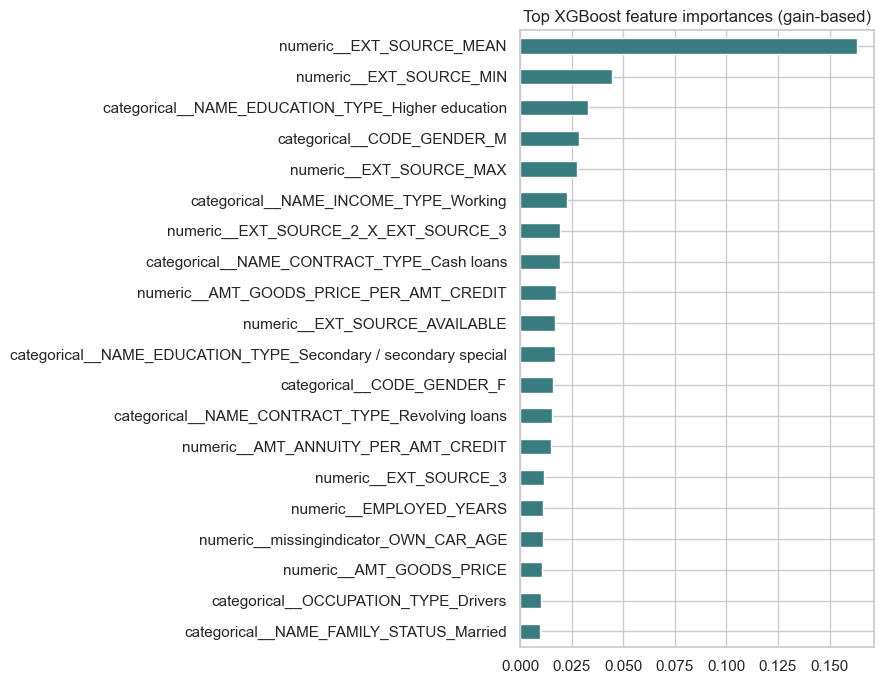

,model,holdout_roc_auc
0,XGBoost baseline,0.754112
1,XGBoost tuned,0.755332


In [22]:
fitted_preprocessor = tuned_model.named_steps['preprocessor']
fitted_xgb = tuned_model.named_steps['model']
importance = pd.Series(
    fitted_xgb.feature_importances_,
    index=fitted_preprocessor.get_feature_names_out(),
    name='gain_importance',
).sort_values(ascending=False)
display(importance.head(30).to_frame())
fig, ax = plt.subplots(figsize=(9, 7))
importance.head(20).sort_values().plot.barh(ax=ax, color='#397c80')
ax.set_title('Top XGBoost feature importances (gain-based)')
plt.tight_layout(); plt.show()

model_comparison = pd.DataFrame({
    'model': ['XGBoost baseline', 'XGBoost tuned'],
    'holdout_roc_auc': [baseline_holdout_auc, tuned_holdout_auc],
})
display(model_comparison)

## 5. Optional Final Fit and Submission

Only enable submission creation after reviewing the untouched holdout result. The final model is refitted using the selected parameters and all labeled training rows. The file contains probabilities for ROC-AUC and preserves test ID order.

In [23]:
if MAKE_SUBMISSION:
    final_xgb = make_pipeline(make_xgb(**{
        key.replace('model__', ''): value for key, value in search.best_params_.items()
    }))
    final_xgb.fit(X, y)
    test_probability = final_xgb.predict_proba(X_test)[:, 1]
    submission = pd.DataFrame({ID_COL: test[ID_COL].to_numpy(), TARGET_COL: test_probability})
    assert submission.columns.tolist() == [ID_COL, TARGET_COL]
    assert submission[ID_COL].equals(test[ID_COL])
    assert submission[TARGET_COL].notna().all()
    assert submission[TARGET_COL].between(0, 1).all()
    output_dir = DATA_ROOT / 'output'
    output_dir.mkdir(exist_ok=True)
    output_path = output_dir / 'submission_xgb_tuned.csv'
    submission.to_csv(output_path, index=False)
    print('Saved:', output_path)
    display(submission.head())
else:
    print('Submission generation is disabled. Set MAKE_SUBMISSION=True to create it after validation.')

Submission generation is disabled. Set MAKE_SUBMISSION=True to create it after validation.
